# Borzoi Performance (AUPRC)

This notebook uses AUPRC (Area Under Precision-Recall Curve) as the primary performance metric.
Positives are defined as genomic bins where the observed signal is in the top 2%.

## 1. Setup and Libraries

In [1]:
# Setup and load required libraries
library(here)
devtools::load_all("/home/aviezerl/src/misha")
library(misha.ext)
library(tidyverse)
library(PRROC)
library(ggrepel)
library(tgstat)
library(tgutil)

options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)
doMC::registerDoMC(cores = 72)

# Source utility functions
source(here("analysis/borzoi_utils.R"))
source(here("analysis/borzoi-plot.R"))

vertical_labs <- function() {
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
}

# Setup misha
setwd(here())
gsetroot("/home/aviezerl/mm10")
gdb.reload()
gdataset.load(here("data/mm10/"), force = T)

here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm



ℹ Loading misha

Attaching package: ‘misha.ext’


The following objects are masked from ‘package:misha’:

    gintervals.mark_overlaps, gintervals.normalize


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::edition_get()   masks testthat::edition_get()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ readr::local_edition() masks testthat::local_edition()
✖ tibble::repair_names() masks misha::repair_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: rlang


Attaching package: ‘rlang’


The following objects are masked from ‘package:purrr’:

    flatten, flatte

## 2. Configuration

In [2]:
# # write observed K27 and K4 tracks the same way they were used to train Borzoi models
# gvtrack.create("obs_k27", "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm", func = "avg", sshift = -500, eshift = 500)
# gvtrack.create("obs_k4", "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3", func = "sum", sshift = -140, eshift = 140)

# gdir.create("seq/IQ/pcg/flashzoi/observed", showWarnings = FALSE)
# gtrack.create(expr = "ifelse(is.na(obs_k27), 0, obs_k27)", track = "seq.IQ.pcg.flashzoi.observed.k27", description = "Observed K27 signal", iterator = 32)
# gtrack.create(expr = "ifelse(is.na(obs_k4), 0, obs_k4)", track = "seq.IQ.pcg.flashzoi.observed.k4", description = "Observed K4 signal", iterator = 32)

In [3]:
# ============================================================
# Configuration
# ============================================================
# Centralized configuration for all analysis parameters

CONFIG <- list(
    # Chromosome splits
    test_chroms = c("chr4", "chr10", "chr14", "chr15"),
    val_chroms = c("chr8", "chr9"),

    # Thresholds
    T_q = 0.98,
    context_size = 0,
    iterator_size = 100,

    # Parallel processing
    n_cores = 72,

    # Reference tracks
    obs_k27_track = "seq.IQ.pcg.flashzoi.observed.k27",
    obs_k4_track = "seq.IQ.pcg.flashzoi.observed.k4",

    # SNS tracks
    sns_lm_track = "jk.epipcg.pred.eb4_xgb_lm_10test_lg_seeds_gc_cg_noX_final",
    sns_brz2k_track = "jk.epipcg.pred.eb4_xgb_brz2k_seeds",


    # Output paths
    output_dir = here("output/borzoi-stats"),

    # Plot styling
    colors = list(
        train = "#2166AC",
        test = "#D6604D",
        val = "#7570B3"
    ),
    
    # RF values for comparison
    rf_values = c("1k", "2k", "4k", "16k", "64k", "128k", "256k", "524k"),
    rf_numeric = c(1024, 2048, 4096, 16384, 65536, 131072, 262144, 524288)
)

# Derived expressions
obs_k27_expr <- CONFIG$obs_k27_track
obs_k4_expr <- paste0("log2(1 + ", CONFIG$obs_k4_track, ")")

# Convenience aliases (for backward compatibility during refactor)
test_chroms <- CONFIG$test_chroms
val_chroms <- CONFIG$val_chroms

message("Configuration loaded successfully")

Configuration loaded successfully



## 3. Helper Functions

In [4]:
# ============================================================
# Helper Functions
# ============================================================

#' Generic track table builder from genome configs
#'
#' @param genome_configs Tribble with genome_dir, genome_label, series, order columns
#' @param track_prefix Prefix for track names (e.g., "seq.IQ.pcg.flashzoi.")
#' @param track_suffix_k27 Suffix for K27 tracks (e.g., ".rf524k_EB4_cnt")
#' @param track_suffix_k4 Suffix for K4 tracks (default: track_suffix_k27 + "_k4")
#' @param col_name_suffix_fn Optional function to modify col_name based on row
#' @return Track table with columns: genome_dir, genome_label, series, order, track_name, col_name, mark
build_track_table <- function(genome_configs, track_prefix, track_suffix_k27, 
                               track_suffix_k4 = NULL,
                               col_name_suffix_fn = function(row) "") {
    if (is.null(track_suffix_k4)) {
        track_suffix_k4 <- paste0(track_suffix_k27, "_k4")
    }
    
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k27),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k27"),
                mark = "K27"
            ) %>%
            ungroup(),
        # K4 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k4),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k4"),
                mark = "K4"
            ) %>%
            ungroup()
    )
    
    return(track_tbl)
}

#' Validate that required tracks exist
#'
#' @param track_tbl Track table with track_name column
#' @param label Label for messages
#' @return TRUE if all tracks exist, FALSE otherwise
validate_tracks <- function(track_tbl, label = "tracks") {
    missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
    if (length(missing_tracks) > 0) {
        message(sprintf("WARNING: Missing %s:", label))
        print(unique(missing_tracks))
        return(FALSE)
    } else {
        message(sprintf("All %d %s found!", nrow(track_tbl), label))
        return(TRUE)
    }
}

message("Helper functions loaded")

Helper functions loaded



## 4. Build rf524k Track Table

In [5]:
# Build track table for rf524k model inferences
# Track naming: seq.IQ.pcg.flashzoi.<genome>.rf524k_EB4_cnt[_k4]

build_rf524k_track_table <- function() {
    # Define genome directories and their labels
    genome_configs <- tribble(
        ~genome_dir, ~genome_label, ~series, ~order,
        # mm10 baseline
        "mm10", "mm10", "baseline", 0,
        # silicusPlus series
        "silicusPlusCGD", "silicus+CGD", "silicusPlus", 1,
        "silicusPlusCRE", "silicus+CRE", "silicusPlus", 2,
        "silicusPlusCTCF", "silicus+CTCF", "silicusPlus", 3,
        "silicusPlusExon", "silicus+Exon", "silicusPlus", 4,
        "silicusPlusTE", "silicus+TE", "silicusPlus", 5,
        "silicusPlusRandom", "silicus+Random", "silicusPlus", 6,
        "silicus", "silicus", "silicusPlus", 7,
        # silicusTelescope series
        "silicus55", "silicus55", "silicusTelescope", 1,
        "silicus65", "silicus65", "silicusTelescope", 2,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescope", 3,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescope", 4,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescope", 5,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescope", 6,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescope", 7,
        # silicusTelescope mm10 series
        "silicus55", "silicus55", "silicusTelescopeMm10", 1,
        "silicus65", "silicus65", "silicusTelescopeMm10", 2,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescopeMm10", 3,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescopeMm10", 4,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescopeMm10", 5,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescopeMm10", 6,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescopeMm10", 7,
        # markovius series
        "markovius", "markovius", "markovius", 1,        
        "markoviusPlusCGDCre", "markovius+CGD+CRE", "markovius", 2,    
        # other
        "silicusPlusCGDExon", "silicus+CGD+Exon", "other", 1,
        "silicusPlusCGDExon", "silicus+CGD+Exon", "otherMm10", 1,
        # mm10Minus series
        "mm10MinusCGD", "mm10-CGD", "mm10Minus", 1,
        "mm10MinusCGDpad1k", "mm10-CGD-pad1k", "mm10Minus", 2,
        "mm10MinusCGDpad2k", "mm10-CGD-pad2k", "mm10Minus", 3,
        "mm10MinusNonCGDCre", "mm10-CRE", "mm10Minus", 4,
        "mm10MinusNonCGDCTCF", "mm10-CTCF", "mm10Minus", 5,
        "mm10MinusNonCGDExon", "mm10-Exon", "mm10Minus", 6,
        "mm10MinusNonCGDTE", "mm10-TE", "mm10Minus", 7,
        "mm10MinusRandom", "mm10-Random", "mm10Minus", 8
    )
    
    # Create track table with K27 and K4 tracks
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope" & genome_dir == "silicus55" ~ paste0("seq.IQ.pcg.flashzoi.silicus55.ft_524k_EB4_cnt_cropped"),
                    series == "silicusTelescope" & genome_dir == "silicus65" ~ paste0("seq.IQ.pcg.flashzoi.silicus.ft_524k_EB4_cnt_cropped"),
                    series == "silicusTelescope"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir == "silicus55" ~ paste0("seq.IQ.pcg.flashzoi.silicus55.ft_mm10_524k_EB4_cnt_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir == "silicus65" ~ paste0("seq.IQ.pcg.flashzoi.silicus.ft_mm10_524k_EB4_cnt_cropped"),
                    series == "silicusTelescopeMm10"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_cropped"),
                    series == "other" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
                    series == "otherMm10" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_cropped"),
                    series == "markovius" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt")
                ),            
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k27"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k27"),
                    TRUE ~ paste0(genome_dir, "_k27")
                ),
                mark = "K27"
            ),
        # K4 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope" & genome_dir == "silicus55" ~ paste0("seq.IQ.pcg.flashzoi.silicus55.ft_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescope" & genome_dir == "silicus65" ~ paste0("seq.IQ.pcg.flashzoi.silicus.ft_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescope"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir == "silicus55" ~ paste0("seq.IQ.pcg.flashzoi.silicus55.ft_mm10_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir == "silicus65" ~ paste0("seq.IQ.pcg.flashzoi.silicus.ft_mm10_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescopeMm10"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_k4_cropped"),
                    series == "other" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
                    series == "otherMm10" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_k4_cropped"),
                    series == "markovius" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt_k4")
                ),
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k4"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k4"),
                    TRUE ~ paste0(genome_dir, "_k4")
                ),
                mark = "K4"
            )
    )
    
    return(track_tbl)
}

track_tbl <- build_rf524k_track_table()

# Verify tracks exist
missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(missing_tracks)
} else {
    message(sprintf("All %d tracks found!", nrow(track_tbl)))
}

# Display track table
track_tbl %>% 
    select(genome_label, series, order, mark, track_name) %>%
    arrange(series, order, mark)

All 68 tracks found!



genome_label,series,order,mark,track_name
<chr>,<chr>,<dbl>,<chr>,<chr>
mm10,baseline,0,K27,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt
mm10,baseline,0,K4,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt_k4
markovius,markovius,1,K27,seq.IQ.pcg.flashzoi.markovius.ft_524k_EB4_cnt_cropped
markovius,markovius,1,K4,seq.IQ.pcg.flashzoi.markovius.ft_524k_EB4_cnt_k4_cropped
markovius+CGD+CRE,markovius,2,K27,seq.IQ.pcg.flashzoi.markoviusPlusCGDCre.ft_524k_EB4_cnt_cropped
markovius+CGD+CRE,markovius,2,K4,seq.IQ.pcg.flashzoi.markoviusPlusCGDCre.ft_524k_EB4_cnt_k4_cropped
mm10-CGD,mm10Minus,1,K27,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt
mm10-CGD,mm10Minus,1,K4,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt_k4
mm10-CGD-pad1k,mm10Minus,2,K27,seq.IQ.pcg.flashzoi.mm10MinusCGDpad1k.rf524k_EB4_cnt


## 5. Load Data and Setup Intervals

In [6]:
# 1. Define splits directly from genome config
all_chroms  <- load_cg_trace_filtered()

intervals_train <- all_chroms %>% filter(!(chrom %in% c(CONFIG$test_chroms, CONFIG$val_chroms)))
intervals_test  <- all_chroms %>% filter(chrom %in% CONFIG$test_chroms)
intervals_val   <- all_chroms %>% filter(chrom %in% CONFIG$val_chroms)

# 2. Create a unified "Master" object
intervals_all <- bind_rows(intervals_train, intervals_test, intervals_val)

message(sprintf("Intervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

Loading cached filtered cg_trace...



Intervals: Train=5448190, Test=1616932, Val=850101



## 6. Compute Overlap Metrics

In [7]:
# Compute AUPRC metrics for K27 and K4 tracks

k27_tracks <- track_tbl %>% filter(mark == "K27")
k4_tracks <- track_tbl %>% filter(mark == "K4")

message("Computing AUPRC for K27 tracks...")
auprc_k27 <- compute_all_track_auprcs(
    track_tbl = k27_tracks,
    intervals = intervals_all,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "auprc-k27.rds")

message("\nComputing AUPRC for K4 tracks...")
auprc_k4 <- compute_all_track_auprcs(
    track_tbl = k4_tracks,
    intervals = intervals_all,
    obs_track_name = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "auprc-k4.rds")

# --- Compute SNS baseline metrics (K27 only) ---
message("\n\nComputing SNS baseline metrics (K27 only)...")

sns_track_tbl <- tibble(
    track_name = c(CONFIG$sns_lm_track, CONFIG$sns_brz2k_track),
    col_name = c("sns_lm", "sns_brz2k"),
    label = c("SNS (linear)", "SNS (Borzoi)")
) 

sns_exists <- all(sapply(sns_track_tbl$track_name, gtrack.exists))
if (sns_exists) {
    auprc_sns <- compute_all_track_auprcs(
        track_tbl = sns_track_tbl,
        intervals = intervals_all,
        obs_track_name = CONFIG$obs_k27_track,
        context_size = CONFIG$context_size,
        T_q = CONFIG$T_q,
        test_chroms = CONFIG$test_chroms,
        val_chroms = CONFIG$val_chroms,
        iterator_size = CONFIG$iterator_size,
        n_cores = CONFIG$n_cores
    ) %cache_rds% file.path(CONFIG$output_dir, "auprc-sns.rds")
    message("\nSNS AUPRC (K27):")
    print(auprc_sns %>% select(col_name, auprc_train, auprc_test, auprc_val))
} else {
    message("WARNING: SNS tracks not found, skipping SNS baseline computation")
    auprc_sns <- NULL
}

message("\nPeak overlap calculation complete!")
message("\nK27 AUPRC:")
print(auprc_k27 %>% arrange(series, order) %>% select(genome_label, series, auprc_train, auprc_test, auprc_val))

Computing AUPRC for K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-k27.rds'


Computing AUPRC for K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-k4.rds'



Computing SNS baseline metrics (K27 only)...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-sns.rds'


SNS AUPRC (K27):



   col_name auprc_train auprc_test auprc_val
1    sns_lm   0.5914397  0.5166745 0.4796577
2 sns_brz2k   0.6435984  0.5610840 0.5991353



Peak overlap calculation complete!


K27 AUPRC:



                   genome_label               series auprc_train auprc_test
1                          mm10             baseline  0.94913762 0.64806674
2                     markovius            markovius  0.02078272 0.01879193
3             markovius+CGD+CRE            markovius  0.72215836 0.60115774
4                      mm10-CGD            mm10Minus  0.52560367 0.34420725
5                mm10-CGD-pad1k            mm10Minus  0.43182944 0.27509984
6                mm10-CGD-pad2k            mm10Minus  0.40068595 0.25627574
7                      mm10-CRE            mm10Minus  0.78604844 0.62637539
8                     mm10-CTCF            mm10Minus  0.79688982 0.63072588
9                     mm10-Exon            mm10Minus  0.79731645 0.62895291
10                      mm10-TE            mm10Minus  0.78819403 0.62648700
11                  mm10-Random            mm10Minus  0.90315390 0.62193131
12             silicus+CGD+Exon                other  0.67538449 0.56940803
13          

## 7. Compute R² Metrics

In [8]:
message(sprintf("Using intervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

compute_r2_metrics <- function(track_tbl, intervals_all, obs_k27_expr, obs_k4_expr) {
    k27_info <- track_tbl %>% filter(mark == "K27")
    k27_info <- track_tbl %>% filter(mark == "K27")
    k4_info <- track_tbl %>% filter(mark == "K4")

    # create virtual tracks
    purrr::walk2(k27_info$track_name, k27_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
    purrr::walk2(k4_info$track_name, k4_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
    purrr::walk2(sns_track_tbl$track_name, sns_track_tbl$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))

    r2_data <- gextract(c(k27_info$col_name, k4_info$col_name, sns_track_tbl$col_name, obs_k27_expr, obs_k4_expr), intervals = intervals_all, iterator = CONFIG$iterator_size, colnames = c(k27_info$col_name, k4_info$col_name, sns_track_tbl$col_name, "obs_k27", "obs_k4")) 

    train_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k27_info$col_name, sns_track_tbl$col_name, "obs_k27"))) %>% as.matrix()
    test_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k27_info$col_name, sns_track_tbl$col_name, "obs_k27"))) %>% as.matrix()
    val_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_val) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k27_info$col_name, sns_track_tbl$col_name, "obs_k27"))) %>% as.matrix()

    k27_train_r2 <- tgs_cor(train_mat_k27[, -ncol(train_mat_k27)], as.matrix(train_mat_k27[, ncol(train_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k27_val_r2 <- tgs_cor(val_mat_k27[, -ncol(val_mat_k27)], as.matrix(val_mat_k27[, ncol(val_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_val = cor)
    k27_test_r2 <- tgs_cor(test_mat_k27[, -ncol(test_mat_k27)], as.matrix(test_mat_k27[, ncol(test_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    train_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k4_info$col_name, "obs_k4"))) %>% as.matrix()
    test_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k4_info$col_name, "obs_k4"))) %>% as.matrix()
    val_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_val) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(k4_info$col_name, "obs_k4"))) %>% as.matrix()

    k4_train_r2 <- tgs_cor(train_mat_k4[, -ncol(train_mat_k4)], as.matrix(train_mat_k4[, ncol(train_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k4_val_r2 <- tgs_cor(val_mat_k4[, -ncol(val_mat_k4)], as.matrix(val_mat_k4[, ncol(val_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_val = cor)
    k4_test_r2 <- tgs_cor(test_mat_k4[, -ncol(test_mat_k4)], as.matrix(test_mat_k4[, ncol(test_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    rsqr_k27 <- left_join(k27_train_r2, k27_val_r2, by = "col_name") %>% 
        left_join(k27_test_r2, by = "col_name") %>% 
        left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name") %>% 
        mutate(r2_train = r2_train^2, r2_test = r2_test^2, r2_val = r2_val^2)

    rsqr_k4 <- left_join(k4_train_r2, k4_val_r2, by = "col_name") %>% 
        left_join(k4_test_r2, by = "col_name") %>% 
        left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name") %>% 
        mutate(r2_train = r2_train^2, r2_test = r2_test^2, r2_val = r2_val^2)

    return(list(rsqr_k27 = rsqr_k27, rsqr_k4 = rsqr_k4))
}

r2_metrics <- compute_r2_metrics(track_tbl, intervals_all, obs_k27_expr, obs_k4_expr) %cache_rds% file.path(CONFIG$output_dir, "r2-metrics.rds")  
rsqr_k27 <- r2_metrics$rsqr_k27 %>% 
    filter(!is.na(genome_label))
rsqr_k4 <- r2_metrics$rsqr_k4
rsqr_sns <- r2_metrics$rsqr_k27 %>% 
    filter(grepl("sns", col_name))

Using intervals: Train=5448190, Test=1616932, Val=850101

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/r2-metrics.rds'



## 8. Build RF Comparison Track Table

In [9]:
# Build track table for receptive field comparison
# Tracks: seq.IQ.pcg.flashzoi.mm10.rf* (pre-training) and seq.IQ.pcg.fm.mm10.rf* (foundation model)

rf_values <- c("1k", "2k", "4k", "8k", "16k", "32k", "64k", "128k", "256k", "524k")
rf_numeric <- c(1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288)

build_rf_comparison_track_table <- function() {
    # Flashzoi mm10 RF tracks (pre-training from scratch)
    flashzoi_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("flashzoi_rf", rf, "_k27"),
        mark = "K27"
    )
    
    flashzoi_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("flashzoi_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Foundation model tracks - base mm10 RF series
    fm_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("fm_rf", rf, "_k27"),
        mark = "K27"
    )
    
    fm_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("fm_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Combine all tracks
    track_tbl <- bind_rows(flashzoi_k27, flashzoi_k4, fm_k27, fm_k4)
    
    return(track_tbl)
}

rf_track_tbl <- build_rf_comparison_track_table()

# Verify tracks exist
missing_tracks <- rf_track_tbl$track_name[!sapply(rf_track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(unique(missing_tracks))
} else {
    message(sprintf("All %d RF comparison tracks found!", nrow(rf_track_tbl)))
}

# Display track table summary
rf_track_tbl %>%
    group_by(series, mark) %>%
    summarise(n_tracks = n(), .groups = "drop") %>%
    print()

All 40 RF comparison tracks found!



# A tibble: 4 x 3
    series mark n_tracks
1 flashzoi  K27       10
2 flashzoi   K4       10
3       fm  K27       10
4       fm   K4       10


In [ ]:
# Extra flashzoi tracks: atac_rna phylop + atac_pcg (only flashzoi exists)
phylop_track_tbl <- bind_rows(
    # atac_rna phylop
    tibble(rf = "524k", rf_numeric = 524288, series = "flashzoi", genome_label = "RF 524k phylop", order = 1,
           track_name = "seq.IQ.atac_rna.flashzoi.mm10.rf524k_phylop_pcg_EB4_cnt",
           col_name = "flashzoi_rf524k_phylop_k27", mark = "K27"),
    tibble(rf = "524k", rf_numeric = 524288, series = "flashzoi", genome_label = "RF 524k phylop", order = 1,
           track_name = "seq.IQ.atac_rna.flashzoi.mm10.rf524k_phylop_pcg_EB4_cnt_k4",
           col_name = "flashzoi_rf524k_phylop_k4", mark = "K4"),
    # atac_pcg
    tibble(rf = "524k", rf_numeric = 524288, series = "flashzoi", genome_label = "RF 524k atac_pcg", order = 2,
           track_name = "seq.IQ.atac_pcg.flashzoi.mm10.rf524k_EB4_cnt",
           col_name = "flashzoi_rf524k_atac_pcg_k27", mark = "K27"),
    tibble(rf = "524k", rf_numeric = 524288, series = "flashzoi", genome_label = "RF 524k atac_pcg", order = 2,
           track_name = "seq.IQ.atac_pcg.flashzoi.mm10.rf524k_EB4_cnt_k4",
           col_name = "flashzoi_rf524k_atac_pcg_k4", mark = "K4")
)

message("Computing AUPRC for phylop + atac_pcg tracks (K27 + K4)...")
phylop_k27 <- phylop_track_tbl %>% filter(mark == "K27")
phylop_k4 <- phylop_track_tbl %>% filter(mark == "K4")
auprc_phylop_k27 <- compute_all_track_auprcs(
    track_tbl = phylop_k27, intervals = intervals_all,
    obs_track_name = CONFIG$obs_k27_track, context_size = CONFIG$context_size, T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms, val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size, n_cores = CONFIG$n_cores
) %fcache_rds% here("output/borzoi-stats/auprc-phylop-k27.rds")
auprc_phylop_k4 <- compute_all_track_auprcs(
    track_tbl = phylop_k4, intervals = intervals_all,
    obs_track_name = CONFIG$obs_k4_track, context_size = CONFIG$context_size, T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms, val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size, n_cores = CONFIG$n_cores
) %fcache_rds% here("output/borzoi-stats/auprc-phylop-k4.rds")
message("AUPRC (K27):"); print(auprc_phylop_k27)
message("AUPRC (K4):"); print(auprc_phylop_k4)

In [ ]:
# Phylop R² – Variant 1: standard intervals (train/val/test)
message("Computing R² for phylop (standard intervals)...")
phylop_r2 <- compute_rf_r2_metrics(phylop_track_tbl, intervals_all, obs_k27_expr, obs_k4_expr) %fcache_rds% here("output/borzoi-stats/rf-r2-phylop.rds")
rsqr_phylop_k27 <- phylop_r2$rsqr_rf_k27
rsqr_phylop_k4 <- phylop_r2$rsqr_rf_k4
message("Phylop R² (standard) K27:"); print(rsqr_phylop_k27)
message("Phylop R² (standard) K4:"); print(rsqr_phylop_k4)

In [ ]:
# Phylop R² – Variant 2: FM vs pretrain intervals (same logic as compute_rf_r2_metrics_fm)
intervals_train_fm <- intervals_train
intervals_test_fm <- gintervals.intersect(intervals_test, "borzoi.test_clean")
phylop_k27_info <- phylop_track_tbl %>% filter(mark == "K27")
phylop_k4_info <- phylop_track_tbl %>% filter(mark == "K4")
intervals_all_fm <- bind_rows(intervals_train_fm, intervals_test_fm)
purrr::walk2(phylop_k27_info$track_name, phylop_k27_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
purrr::walk2(phylop_k4_info$track_name, phylop_k4_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
r2_data_phylop <- gextract(c(phylop_k27_info$col_name, phylop_k4_info$col_name, obs_k27_expr, obs_k4_expr),
    intervals = intervals_all_fm, iterator = CONFIG$iterator_size, colnames = c(phylop_k27_info$col_name, phylop_k4_info$col_name, "obs_k27", "obs_k4"))
train_mat_k27 <- r2_data_phylop %>% gintervals.neighbors(intervals_train_fm) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% select(all_of(c(phylop_k27_info$col_name, "obs_k27"))) %>% as.matrix()
test_mat_k27 <- r2_data_phylop %>% gintervals.neighbors(intervals_test_fm) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% select(all_of(c(phylop_k27_info$col_name, "obs_k27"))) %>% as.matrix()
k27_train_r2 <- tgs_cor(train_mat_k27[, -ncol(train_mat_k27)], as.matrix(train_mat_k27[, ncol(train_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% select(col_name = col1, r2_train = cor)
k27_test_r2 <- tgs_cor(test_mat_k27[, -ncol(test_mat_k27)], as.matrix(test_mat_k27[, ncol(test_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% select(col_name = col1, r2_test = cor)
train_mat_k4 <- r2_data_phylop %>% gintervals.neighbors(intervals_train_fm) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% select(all_of(c(phylop_k4_info$col_name, "obs_k4"))) %>% as.matrix()
test_mat_k4 <- r2_data_phylop %>% gintervals.neighbors(intervals_test_fm) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% select(all_of(c(phylop_k4_info$col_name, "obs_k4"))) %>% as.matrix()
k4_train_r2 <- tgs_cor(train_mat_k4[, -ncol(train_mat_k4)], as.matrix(train_mat_k4[, ncol(train_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% select(col_name = col1, r2_train = cor)
k4_test_r2 <- tgs_cor(test_mat_k4[, -ncol(test_mat_k4)], as.matrix(test_mat_k4[, ncol(test_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% select(col_name = col1, r2_test = cor)
rsqr_phylop_k27_fm <- left_join(k27_train_r2, k27_test_r2, by = "col_name") %>% left_join(phylop_track_tbl %>% filter(mark == "K27") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")
rsqr_phylop_k4_fm <- left_join(k4_train_r2, k4_test_r2, by = "col_name") %>% left_join(phylop_track_tbl %>% filter(mark == "K4") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")
phylop_r2_fm <- list(rsqr_rf_k27 = rsqr_phylop_k27_fm, rsqr_rf_k4 = rsqr_phylop_k4_fm) %fcache_rds% here("output/borzoi-stats/rf-r2-phylop-fm-pretrain.rds")
message("Phylop R² (FM vs pretrain) K27:"); print(rsqr_phylop_k27_fm)
message("Phylop R² (FM vs pretrain) K4:"); print(rsqr_phylop_k4_fm)

In [ ]:
# Phylop AUPRC – Variant 2: borzoi clean folds (FM vs pretrain intervals)
intervals_train_fm <- intervals_train
intervals_test_fm <- gintervals.intersect(intervals_test, "borzoi.test_clean")

compute_track_auprc_custom <- function(track_name, obs_track_name, intervals_train, intervals_test, T_q = CONFIG$T_q, context_size = CONFIG$context_size, iterator_size = CONFIG$iterator_size) {
    obs_track_tmp <- "obs_auprc_raw"
    pred_track_tmp <- "pred_auprc_raw"
    intervals_train_clean <- intervals_train %>% select(chrom, start, end)
    intervals_test_clean <- intervals_test %>% select(chrom, start, end)
    intervals_all <- bind_rows(intervals_train_clean, intervals_test_clean)
    gvtrack.create(obs_track_tmp, obs_track_name, "avg")
    gvtrack.create(pred_track_tmp, track_name, "avg")
    if (context_size > 0) {
        gvtrack.iterator(obs_track_tmp, sshift = -context_size, eshift = context_size)
        gvtrack.iterator(pred_track_tmp, sshift = -context_size, eshift = context_size)
    }
    d_all <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_all, iterator = iterator_size)
    d_train <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_train_clean, iterator = iterator_size)
    d_test <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_test_clean, iterator = iterator_size)
    tryCatch({ gvtrack.rm(obs_track_tmp); gvtrack.rm(pred_track_tmp) }, error = function(e) {})
    obs_col <- names(d_all)[grepl("obs", names(d_all))][1]
    pred_col <- names(d_all)[grepl("pred", names(d_all))][1]
    d_all[[obs_col]][is.nan(d_all[[obs_col]]) | is.na(d_all[[obs_col]])] <- 0
    d_all[[pred_col]][is.nan(d_all[[pred_col]]) | is.na(d_all[[pred_col]])] <- 0
    d_train[[obs_col]][is.nan(d_train[[obs_col]]) | is.na(d_train[[obs_col]])] <- 0
    d_train[[pred_col]][is.nan(d_train[[pred_col]]) | is.na(d_train[[pred_col]])] <- 0
    d_test[[obs_col]][is.nan(d_test[[obs_col]]) | is.na(d_test[[obs_col]])] <- 0
    d_test[[pred_col]][is.nan(d_test[[pred_col]]) | is.na(d_test[[pred_col]])] <- 0
    d_all$obs_val <- d_all[[obs_col]]
    d_all$pred_val <- d_all[[pred_col]]
    d_train$obs_val <- d_train[[obs_col]]
    d_train$pred_val <- d_train[[pred_col]]
    d_test$obs_val <- d_test[[obs_col]]
    d_test$pred_val <- d_test[[pred_col]]
    q_obs <- quantile(d_all$obs_val, T_q, na.rm = TRUE)
    calc_auprc <- function(obs_vals, pred_vals) {
        labels <- as.integer(obs_vals > q_obs)
        if (sum(labels == 1) == 0 || sum(labels == 0) == 0) return(NA)
        pr <- PRROC::pr.curve(scores.class0 = pred_vals[labels == 1], scores.class1 = pred_vals[labels == 0])
        return(pr$auc.integral)
    }
    c(auprc_train = calc_auprc(d_train$obs_val, d_train$pred_val), auprc_test = calc_auprc(d_test$obs_val, d_test$pred_val))
}

phylop_k27 <- phylop_track_tbl %>% filter(mark == "K27")
phylop_k4 <- phylop_track_tbl %>% filter(mark == "K4")
message("Computing AUPRC for phylop (borzoi clean folds)...")
auprc_phylop_k27_fm <- plyr::adply(phylop_k27, 1, function(row) {
    tryCatch({
        m <- compute_track_auprc_custom(row$track_name, CONFIG$obs_k27_track, intervals_train_fm, intervals_test_fm)
        data.frame(col_name = row$col_name, auprc_train = m["auprc_train"], auprc_test = m["auprc_test"])
    }, error = function(e) data.frame(col_name = row$col_name, auprc_train = NA_real_, auprc_test = NA_real_))
}) %fcache_rds% here("output/borzoi-stats/auprc-phylop-k27-fm-pretrain.rds")
auprc_phylop_k4_fm <- plyr::adply(phylop_k4, 1, function(row) {
    tryCatch({
        m <- compute_track_auprc_custom(row$track_name, CONFIG$obs_k4_track, intervals_train_fm, intervals_test_fm)
        data.frame(col_name = row$col_name, auprc_train = m["auprc_train"], auprc_test = m["auprc_test"])
    }, error = function(e) data.frame(col_name = row$col_name, auprc_train = NA_real_, auprc_test = NA_real_))
}) %fcache_rds% here("output/borzoi-stats/auprc-phylop-k4-fm-pretrain.rds")
message("Phylop AUPRC (borzoi clean) K27:"); print(auprc_phylop_k27_fm)
message("Phylop AUPRC (borzoi clean) K4:"); print(auprc_phylop_k4_fm)

## 9. Compute RF Overlap

In [10]:
# Compute AUPRC metrics for RF comparison tracks
# Uses compute_all_track_auprcs from borzoi_utils.R

rf_k27_tracks <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_tracks <- rf_track_tbl %>% filter(mark == "K4")

message("Computing AUPRC for RF comparison K27 tracks...")
auprc_rf_k27 <- compute_all_track_auprcs(
    track_tbl = rf_k27_tracks,
    intervals = intervals_all,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% here("output/borzoi-stats/auprc-rf-k27.rds")

message("\nComputing AUPRC for RF comparison K4 tracks...")
auprc_rf_k4 <- compute_all_track_auprcs(
    track_tbl = rf_k4_tracks,
    intervals = intervals_all,
    obs_track_name = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% here("output/borzoi-stats/auprc-rf-k4.rds")

message("\nRF AUPRC calculation complete!")
message("\nK27 RF AUPRC summary:")
print(auprc_rf_k27)
message("\nK4 RF AUPRC summary:")
print(auprc_rf_k4)

Computing AUPRC for RF comparison K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-rf-k27.rds'


Computing AUPRC for RF comparison K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-rf-k4.rds'


RF AUPRC calculation complete!


K27 RF AUPRC summary:



     rf rf_numeric   series genome_label order
1    1k       1024 flashzoi        RF 1k     1
2    2k       2048 flashzoi        RF 2k     2
3    4k       4096 flashzoi        RF 4k     3
4    8k       8192 flashzoi        RF 8k     4
5   16k      16384 flashzoi       RF 16k     5
6   32k      32768 flashzoi       RF 32k     6
7   64k      65536 flashzoi       RF 64k     7
8  128k     131072 flashzoi      RF 128k     8
9  256k     262144 flashzoi      RF 256k     9
10 524k     524288 flashzoi      RF 524k    10
11   1k       1024       fm        RF 1k     1
12   2k       2048       fm        RF 2k     2
13   4k       4096       fm        RF 4k     3
14   8k       8192       fm        RF 8k     4
15  16k      16384       fm       RF 16k     5
16  32k      32768       fm       RF 32k     6
17  64k      65536       fm       RF 64k     7
18 128k     131072       fm      RF 128k     8
19 256k     262144       fm      RF 256k     9
20 524k     524288       fm      RF 524k    10
             


K4 RF AUPRC summary:



     rf rf_numeric   series genome_label order
1    1k       1024 flashzoi        RF 1k     1
2    2k       2048 flashzoi        RF 2k     2
3    4k       4096 flashzoi        RF 4k     3
4    8k       8192 flashzoi        RF 8k     4
5   16k      16384 flashzoi       RF 16k     5
6   32k      32768 flashzoi       RF 32k     6
7   64k      65536 flashzoi       RF 64k     7
8  128k     131072 flashzoi      RF 128k     8
9  256k     262144 flashzoi      RF 256k     9
10 524k     524288 flashzoi      RF 524k    10
11   1k       1024       fm        RF 1k     1
12   2k       2048       fm        RF 2k     2
13   4k       4096       fm        RF 4k     3
14   8k       8192       fm        RF 8k     4
15  16k      16384       fm       RF 16k     5
16  32k      32768       fm       RF 32k     6
17  64k      65536       fm       RF 64k     7
18 128k     131072       fm      RF 128k     8
19 256k     262144       fm      RF 256k     9
20 524k     524288       fm      RF 524k    10
             

## 10. Compute RF R²

In [11]:
# Compute R^2 metrics for RF comparison tracks
# Uses same strategy as compute_r2_metrics function
message(sprintf("Using intervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

compute_rf_r2_metrics <- function(rf_track_tbl, intervals_all, obs_k27_expr, obs_k4_expr) {
    rf_k27_info <- rf_track_tbl %>% filter(mark == "K27")
    rf_k4_info <- rf_track_tbl %>% filter(mark == "K4")

    # create virtual tracks
    purrr::walk2(rf_k27_info$track_name, rf_k27_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
    purrr::walk2(rf_k4_info$track_name, rf_k4_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))

    r2_data <- gextract(c(rf_k27_info$col_name, rf_k4_info$col_name, obs_k27_expr, obs_k4_expr), intervals = intervals_all, iterator = CONFIG$iterator_size, colnames = c(rf_k27_info$col_name, rf_k4_info$col_name, "obs_k27", "obs_k4")) 

    train_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k27_info$col_name, "obs_k27"))) %>% as.matrix()
    test_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k27_info$col_name, "obs_k27"))) %>% as.matrix()
    val_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_val) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k27_info$col_name, "obs_k27"))) %>% as.matrix()

    k27_train_r2 <- tgs_cor(train_mat_k27[, -ncol(train_mat_k27)], as.matrix(train_mat_k27[, ncol(train_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k27_val_r2 <- tgs_cor(val_mat_k27[, -ncol(val_mat_k27)], as.matrix(val_mat_k27[, ncol(val_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_val = cor)
    k27_test_r2 <- tgs_cor(test_mat_k27[, -ncol(test_mat_k27)], as.matrix(test_mat_k27[, ncol(test_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    train_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k4_info$col_name, "obs_k4"))) %>% as.matrix()
    test_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k4_info$col_name, "obs_k4"))) %>% as.matrix()
    val_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_val) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k4_info$col_name, "obs_k4"))) %>% as.matrix()

    k4_train_r2 <- tgs_cor(train_mat_k4[, -ncol(train_mat_k4)], as.matrix(train_mat_k4[, ncol(train_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k4_val_r2 <- tgs_cor(val_mat_k4[, -ncol(val_mat_k4)], as.matrix(val_mat_k4[, ncol(val_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_val = cor)
    k4_test_r2 <- tgs_cor(test_mat_k4[, -ncol(test_mat_k4)], as.matrix(test_mat_k4[, ncol(test_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    rsqr_rf_k27 <- left_join(k27_train_r2, k27_val_r2, by = "col_name") %>% 
        left_join(k27_test_r2, by = "col_name") %>% 
        mutate(r2_train = r2_train^2, r2_val = r2_val^2, r2_test = r2_test^2) %>%
        left_join(rf_track_tbl %>% filter(mark == "K27") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

    rsqr_rf_k4 <- left_join(k4_train_r2, k4_val_r2, by = "col_name") %>% 
        left_join(k4_test_r2, by = "col_name") %>% 
        mutate(r2_train = r2_train^2, r2_val = r2_val^2, r2_test = r2_test^2) %>%
        left_join(rf_track_tbl %>% filter(mark == "K4") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

    return(list(rsqr_rf_k27 = rsqr_rf_k27, rsqr_rf_k4 = rsqr_rf_k4))
}

obs_k27_expr <- CONFIG$obs_k27_track
obs_k4_expr <- paste0("log2(1 + ", CONFIG$obs_k4_track, ")")

message("Calculating R^2 for RF comparison tracks...")
rf_r2_metrics <- compute_rf_r2_metrics(rf_track_tbl, intervals_all, obs_k27_expr, obs_k4_expr) %cache_rds% here("output/borzoi-stats/rf-r2-metrics.rds")
rsqr_rf_k27 <- rf_r2_metrics$rsqr_rf_k27
rsqr_rf_k4 <- rf_r2_metrics$rsqr_rf_k4

message("\nRF R^2 calculation complete!")
message("\nK27 RF R^2 summary:")
print(rsqr_rf_k27)
message("\nK4 RF R^2 summary:")
print(rsqr_rf_k4)


Using intervals: Train=5448190, Test=1616932, Val=850101

Calculating R^2 for RF comparison tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rf-r2-metrics.rds'


RF R^2 calculation complete!


K27 RF R^2 summary:



              col_name  r2_train    r2_val   r2_test   rf rf_numeric   series
1    flashzoi_rf1k_k27 0.3538262 0.2763318 0.3049781   1k       1024 flashzoi
2    flashzoi_rf2k_k27 0.4450672 0.3434413 0.3734967   2k       2048 flashzoi
3    flashzoi_rf4k_k27 0.5745902 0.4497879 0.4727262   4k       4096 flashzoi
4    flashzoi_rf8k_k27 0.6422985 0.5176964 0.5329167   8k       8192 flashzoi
5   flashzoi_rf16k_k27 0.6985896 0.5626361 0.5752709  16k      16384 flashzoi
6   flashzoi_rf32k_k27 0.6814627 0.5690645 0.5969572  32k      32768 flashzoi
7   flashzoi_rf64k_k27 0.7444623 0.5862107 0.6087173  64k      65536 flashzoi
8  flashzoi_rf128k_k27 0.7541038 0.6043724 0.6153422 128k     131072 flashzoi
9  flashzoi_rf256k_k27 0.7398419 0.5867882 0.6080466 256k     262144 flashzoi
10 flashzoi_rf524k_k27 0.8749234 0.6121039 0.6364033 524k     524288 flashzoi
11         fm_rf1k_k27 0.3076514 0.2773919 0.3087341   1k       1024       fm
12         fm_rf2k_k27 0.4083525 0.3787155 0.4046063   2k       


K4 RF R^2 summary:



             col_name  r2_train    r2_val   r2_test   rf rf_numeric   series
1    flashzoi_rf1k_k4 0.4552083 0.3120055 0.3168773   1k       1024 flashzoi
2    flashzoi_rf2k_k4 0.4265724 0.3205800 0.3240867   2k       2048 flashzoi
3    flashzoi_rf4k_k4 0.4699862 0.3665637 0.3726378   4k       4096 flashzoi
4    flashzoi_rf8k_k4 0.4589892 0.3703178 0.3764865   8k       8192 flashzoi
5   flashzoi_rf16k_k4 0.4856070 0.3959318 0.4063463  16k      16384 flashzoi
6   flashzoi_rf32k_k4 0.4486920 0.3867866 0.3981970  32k      32768 flashzoi
7   flashzoi_rf64k_k4 0.4380908 0.3627419 0.3716687  64k      65536 flashzoi
8  flashzoi_rf128k_k4 0.4713762 0.3912249 0.3991412 128k     131072 flashzoi
9  flashzoi_rf256k_k4 0.4411820 0.3678258 0.3733719 256k     262144 flashzoi
10 flashzoi_rf524k_k4 0.4968281 0.3906847 0.3956696 524k     524288 flashzoi
11         fm_rf1k_k4 0.3577158 0.3292868 0.3357529   1k       1024       fm
12         fm_rf2k_k4 0.3750494 0.3537855 0.3595931   2k       2048       fm

In [12]:
# Compute R^2 metrics for RF comparison tracks using train_mod_gw and val_mod_gw
# For FM vs pretrain comparison: train = train_mod_gw (training chromosomes), test = val_mod_gw (validation chromosomes)

# Ensure rf_track_tbl and rf_k27_info/rf_k4_info are defined
if (!exists("rf_track_tbl")) {
    rf_track_tbl <- build_rf_comparison_track_table()
}
rf_k27_info <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_info <- rf_track_tbl %>% filter(mark == "K4")

# Define observation expressions if not already defined
if (!exists("obs_k27_expr")) {
    obs_k27_expr <- CONFIG$obs_k27_track
}
if (!exists("obs_k4_expr")) {
    obs_k4_expr <- paste0("log2(1 + ", CONFIG$obs_k4_track, ")")
}

# For FM vs Pretrain: train = training chromosomes, test = test chromosomes intersected with borzoi.test_clean
intervals_train_fm <- intervals_train
intervals_test_fm <- gintervals.intersect(intervals_test, "borzoi.test_clean")

message("FM vs Pretrain intervals:")
message(sprintf("Train: %d intervals", nrow(intervals_train_fm)))
message(sprintf("Test:  %d intervals", nrow(intervals_test_fm)))
message(sprintf("Number of BP covered by test intervals: %d", gintervals.covered_bp(intervals_test_fm)))

# Recompute R^2 for RF series using FM vs pretrain intervals
# Uses same strategy as compute_r2_metrics function
message(sprintf("Using intervals: Train=%d, Test=%d", 
                nrow(intervals_train_fm), nrow(intervals_test_fm)))

compute_rf_r2_metrics_fm <- function(rf_track_tbl, intervals_train, intervals_test, obs_k27_expr, obs_k4_expr) {
    rf_k27_info <- rf_track_tbl %>% filter(mark == "K27")
    rf_k4_info <- rf_track_tbl %>% filter(mark == "K4")

    # Combine intervals for extraction
    intervals_all <- bind_rows(intervals_train, intervals_test)

    # create virtual tracks
    purrr::walk2(rf_k27_info$track_name, rf_k27_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))
    purrr::walk2(rf_k4_info$track_name, rf_k4_info$col_name, ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))

    r2_data <- gextract(c(rf_k27_info$col_name, rf_k4_info$col_name, obs_k27_expr, obs_k4_expr), intervals = intervals_all, iterator = CONFIG$iterator_size, colnames = c(rf_k27_info$col_name, rf_k4_info$col_name, "obs_k27", "obs_k4")) 

    train_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k27_info$col_name, "obs_k27"))) %>% as.matrix()
    test_mat_k27 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k27_info$col_name, "obs_k27"))) %>% as.matrix()

    k27_train_r2 <- tgs_cor(train_mat_k27[, -ncol(train_mat_k27)], as.matrix(train_mat_k27[, ncol(train_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k27_test_r2 <- tgs_cor(test_mat_k27[, -ncol(test_mat_k27)], as.matrix(test_mat_k27[, ncol(test_mat_k27)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    train_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_train) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k4_info$col_name, "obs_k4"))) %>% as.matrix()
    test_mat_k4 <- r2_data %>% gintervals.neighbors(intervals_test) %>% filter(dist == 0) %>% select(-dist, -chrom1, -start1, -end1) %>% 
        select(all_of(c(rf_k4_info$col_name, "obs_k4"))) %>% as.matrix()

    k4_train_r2 <- tgs_cor(train_mat_k4[, -ncol(train_mat_k4)], as.matrix(train_mat_k4[, ncol(train_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_train = cor)
    k4_test_r2 <- tgs_cor(test_mat_k4[, -ncol(test_mat_k4)], as.matrix(test_mat_k4[, ncol(test_mat_k4)]), pairwise.complete.obs = TRUE, tidy = TRUE) %>% 
        select(col_name = col1, r2_test = cor)

    rsqr_rf_k27 <- left_join(k27_train_r2, k27_test_r2, by = "col_name") %>% 
        left_join(rf_track_tbl %>% filter(mark == "K27") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

    rsqr_rf_k4 <- left_join(k4_train_r2, k4_test_r2, by = "col_name") %>% 
        left_join(rf_track_tbl %>% filter(mark == "K4") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

    return(list(rsqr_rf_k27 = rsqr_rf_k27, rsqr_rf_k4 = rsqr_rf_k4))
}

message("\nCalculating R^2 for RF comparison tracks (FM vs Pretrain)...")
rf_r2_metrics_fm <- compute_rf_r2_metrics_fm(rf_track_tbl, intervals_train_fm, intervals_test_fm, obs_k27_expr, obs_k4_expr) %cache_rds% here("output/borzoi-stats/rf-r2-metrics-fm-pretrain.rds")
rsqr_rf_k27_fm <- rf_r2_metrics_fm$rsqr_rf_k27
rsqr_rf_k4_fm <- rf_r2_metrics_fm$rsqr_rf_k4


message("\nRF R^2 calculation complete (FM vs Pretrain)!")
message("\nK27 RF R^2 summary (FM vs Pretrain):")
print(rsqr_rf_k27_fm %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))
message("\nK4 RF R^2 summary (FM vs Pretrain):")
print(rsqr_rf_k4_fm %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))


FM vs Pretrain intervals:

Train: 5448190 intervals

Test:  66541 intervals

Number of BP covered by test intervals: 104251840

Using intervals: Train=5448190, Test=66541


Calculating R^2 for RF comparison tracks (FM vs Pretrain)...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rf-r2-metrics-fm-pretrain.rds'


RF R^2 calculation complete (FM vs Pretrain)!


K27 RF R^2 summary (FM vs Pretrain):



# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.6694218
2       fm 10    0.6815551



K4 RF R^2 summary (FM vs Pretrain):



# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.5736564
2       fm 10    0.5853568


In [13]:

# Helper function to compute AUPRC with custom train/test intervals
compute_track_auprc_custom <- function(track_name, obs_track_name, intervals_train, intervals_test, T_q = CONFIG$T_q, context_size = CONFIG$context_size, iterator_size = CONFIG$iterator_size) {   
    obs_track_tmp <- "obs_auprc_raw"
    pred_track_tmp <- "pred_auprc_raw"
    
    # Combine intervals for threshold calculation
    # Ensure both intervals have the same columns (gintervals.intersect may add extra columns)
    intervals_train_clean <- intervals_train %>% select(chrom, start, end)
    intervals_test_clean <- intervals_test %>% select(chrom, start, end)
    intervals_all <- bind_rows(intervals_train_clean, intervals_test_clean)
    
    # Create virtual tracks with context
    gvtrack.create(obs_track_tmp, obs_track_name, "avg")
    gvtrack.create(pred_track_tmp, track_name, "avg")
    
    if (context_size > 0) {
        gvtrack.iterator(obs_track_tmp, sshift = -context_size, eshift = context_size)
        gvtrack.iterator(pred_track_tmp, sshift = -context_size, eshift = context_size)
    }
    
    # Extract values for all intervals
    d_all <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_all, iterator = iterator_size)
    
    # Extract values for train intervals
    d_train <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_train_clean, iterator = iterator_size)
    
    # Extract values for test intervals
    d_test <- gextract(c(obs_track_tmp, pred_track_tmp), intervals = intervals_test_clean, iterator = iterator_size)
    
    # Clean up temporary tracks
    tryCatch({
        gvtrack.rm(obs_track_tmp)
        gvtrack.rm(pred_track_tmp)
    }, error = function(e) {
        # Ignore cleanup errors (track might already be removed)
    })
    
    # Get column names dynamically (they will have the unique suffix)
    obs_col <- names(d_all)[grepl("obs", names(d_all))][1]
    pred_col <- names(d_all)[grepl("pred", names(d_all))][1]
    
    # Replace NaN/NA with 0
    d_all[[obs_col]][is.nan(d_all[[obs_col]]) | is.na(d_all[[obs_col]])] <- 0
    d_all[[pred_col]][is.nan(d_all[[pred_col]]) | is.na(d_all[[pred_col]])] <- 0
    d_train[[obs_col]][is.nan(d_train[[obs_col]]) | is.na(d_train[[obs_col]])] <- 0
    d_train[[pred_col]][is.nan(d_train[[pred_col]]) | is.na(d_train[[pred_col]])] <- 0
    d_test[[obs_col]][is.nan(d_test[[obs_col]]) | is.na(d_test[[obs_col]])] <- 0
    d_test[[pred_col]][is.nan(d_test[[pred_col]]) | is.na(d_test[[pred_col]])] <- 0
    
    # Rename for clarity
    d_all$obs_val <- d_all[[obs_col]]
    d_all$pred_val <- d_all[[pred_col]]
    d_train$obs_val <- d_train[[obs_col]]
    d_train$pred_val <- d_train[[pred_col]]
    d_test$obs_val <- d_test[[obs_col]]
    d_test$pred_val <- d_test[[pred_col]]
    
    # Compute global threshold for positives (top 2% of observed) using all data
    q_obs <- quantile(d_all$obs_val, T_q, na.rm = TRUE)
    
    # Helper to compute AUPRC
    calc_auprc <- function(obs_vals, pred_vals) {
        labels <- as.integer(obs_vals > q_obs)
        if (sum(labels == 1) == 0 || sum(labels == 0) == 0) {
            return(NA)
        }
        pr <- PRROC::pr.curve(
            scores.class0 = pred_vals[labels == 1],
            scores.class1 = pred_vals[labels == 0]
        )
        return(pr$auc.integral)
    }
    
    # Calculate AUPRC for train and test
    auprc_train <- calc_auprc(d_train$obs_val, d_train$pred_val)
    auprc_test <- calc_auprc(d_test$obs_val, d_test$pred_val)
    
    return(c(auprc_train = auprc_train, auprc_test = auprc_test))
}

# Recompute AUPRC for RF series using FM vs pretrain intervals
message("\nComputing AUPRC for RF comparison K27 tracks (FM vs Pretrain)...")
doMC::registerDoMC(cores = 50)
auprc_rf_k27_fm_results <- plyr::adply(rf_k27_info, 1, function(row) {
    tryCatch({
        metrics <- compute_track_auprc_custom(
            track_name = row$track_name,
            obs_track_name = CONFIG$obs_k27_track,
            intervals_train = intervals_train_fm,
            intervals_test = intervals_test_fm,
            T_q = CONFIG$T_q,
            context_size = CONFIG$context_size,
            iterator_size = CONFIG$iterator_size
        )
        data.frame(
            col_name = row$col_name,
            auprc_train = metrics["auprc_train"],
            auprc_test = metrics["auprc_test"]
        )
    }, error = function(e) {
        message(sprintf("  ERROR processing %s: %s", row$col_name, e$message))
        data.frame(col_name = row$col_name, auprc_train = NA, auprc_test = NA)
    })
}, .parallel = TRUE) %cache_rds% here("output/borzoi-stats/auprc-rf-k27-fm-pretrain.rds")


message("Computing AUPRC for RF comparison K4 tracks (FM vs Pretrain)...")
auprc_rf_k4_fm_results <- plyr::adply(rf_k4_info, 1, function(row) {
    tryCatch({
        metrics <- compute_track_auprc_custom(
            track_name = row$track_name,
            obs_track_name = CONFIG$obs_k4_track,
            intervals_train = intervals_train_fm,
            intervals_test = intervals_test_fm,
            T_q = CONFIG$T_q,
            context_size = CONFIG$context_size,
            iterator_size = CONFIG$iterator_size
        )
        data.frame(
            col_name = row$col_name,
            auprc_train = metrics["auprc_train"],
            auprc_test = metrics["auprc_test"]
        )
    }, error = function(e) {
        message(sprintf("  ERROR processing %s: %s", row$col_name, e$message))
        data.frame(col_name = row$col_name, auprc_train = NA, auprc_test = NA)
    })
}, .parallel = TRUE) %cache_rds% here("output/borzoi-stats/auprc-rf-k4-fm-pretrain.rds")





Computing AUPRC for RF comparison K27 tracks (FM vs Pretrain)...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-rf-k27-fm-pretrain.rds'

Computing AUPRC for RF comparison K4 tracks (FM vs Pretrain)...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-rf-k4-fm-pretrain.rds'



## 11. RF Plot Functions

In [14]:
#' Plot RF comparison overlap with RF values on x-axis
#'
#' @param overlap_data Main overlap data frame with auprc_train, auprc_test, val_p columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_overlap <- function(overlap_data, mark_label, series_name, title_suffix = "", 
                                       show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- overlap_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("auprc_train", "auprc_test")
    name_map <- c(train_p = "Train", test_p = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "auprc_val")
        name_map <- c(name_map, val_p = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "overlap") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = overlap, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(overlap, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = "AUPRC",
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

#' Plot RF comparison R^2 with RF values on x-axis
#'
#' @param rsqr_data Main rsqr data frame with r2_train, r2_test, r2_val columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_rsqr <- function(rsqr_data, mark_label, series_name, title_suffix = "", 
                                    show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- rsqr_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("r2_train", "r2_test")
    name_map <- c(r2_train = "Train", r2_test = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "r2_val")
        name_map <- c(name_map, r2_val = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "r2") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = r2, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(r2, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = expression(R^2),
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

## 12. Create Combined Plot

In [15]:
library(patchwork)

# --- 1. Prepare Data & Helpers ---

# Shared Y-axis limit for alignment
common_ylim <- c(0, 0.8)
common_ylim_r2 <- c(0, 0.7)

# Helper to clean Y-axis for inner plots (removes labels/ticks for tighter packing)
clean_y_axis <- function() {
    theme(
        axis.title.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )
}

# Levels for x-axes
mm10_short_levels <- c("-CGD", "-CRE", "-CTCF", "-Exon", "-TE", "10% S.")
tel_short_levels <- c("silicus55", "silicus65", "+CGD", "+CRE", "+CTCF", "+Exon", "+TE")
telescope_mapping <- c(
    "silicus55" = "silicus55", "silicus65" = "silicus65", "silicus+CGD" = "+CGD", "silicus+CGD+CRE" = "+CRE",
    "silicus+CGD+CRE+CTCF" = "+CTCF", "silicus+CGD+CRE+CTCF+Exon" = "+Exon", 
    "silicus+CGD+CRE+CTCF+Exon+TE" = "+TE"
)

# --- 2. Create Row 1: AUPRC ---

# Plot 1: FM Receptive Field (Overlap)
p1_auprc_fm <- plot_rf_comparison_overlap(
    auprc_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab("AUPRC") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 2: mm10Minus (Overlap)
p2_auprc_minus <- plot_performance(
    auprc_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "auprc",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis() # Remove y-axis for alignment

# Plot 3: Telescope (Overlap)
p3_auprc_tel <- plot_performance(
    auprc_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "auprc",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 3. Create Row 2: R^2 ---

# Plot 4: FM Receptive Field (R2)
p4_rsqr_fm <- plot_rf_comparison_rsqr(
    rsqr_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab(expression(R^2)) +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 5: mm10Minus (R2)
p5_rsqr_minus <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Plot 6: Telescope (R2)
p6_rsqr_tel <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 4. Combine with Patchwork & Export ---

# Combine plots: (Row 1) over (Row 2), collecting guides
combined_plot <- (p1_auprc_fm | p2_auprc_minus | p3_auprc_tel) /
                 (p4_rsqr_fm | p5_rsqr_minus | p6_rsqr_tel) +
                 plot_layout(guides = "collect", axis_titles = "collect") & 
                 theme(legend.position = "top", 
                       plot.margin = margin(5, 5, 5, 5))

# Export to single slide
ppt_path_all <- here("figures/k27_all_comparison.pptx")
tgppt::plot_base_ppt(print(combined_plot), ppt_path_all, width = 18, height = 12, overwrite = TRUE) # Wider width for 3 columns

message("Combined aligned plot saved to ", ppt_path_all)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


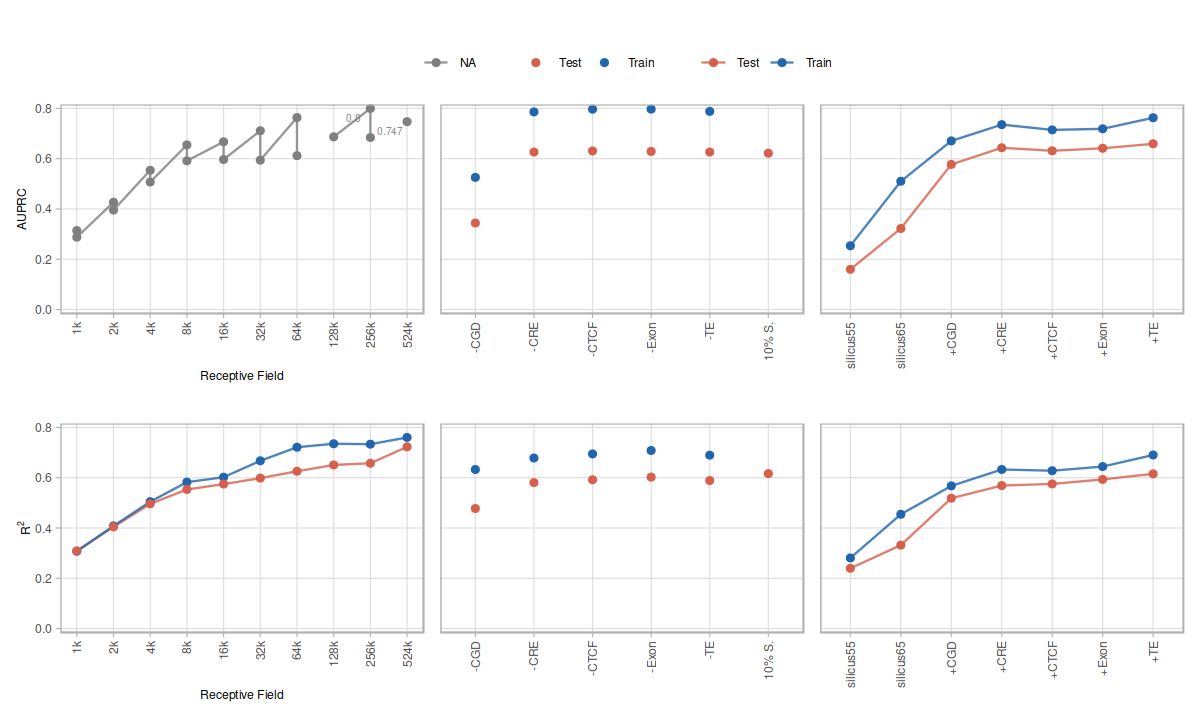

In [16]:
sps(10, 6)
combined_plot

## 13. Combined Plot with silicusTelescopeMm10 (Supplementary)

In [17]:
# --- Combined Plot with silicusTelescopeMm10 variant ---
# Same structure as above but using silicusTelescopeMm10 instead of silicusTelescope

# Plot 3b: Telescope Mm10 (Overlap)
p3b_auprc_tel_mm10 <- plot_performance(
    auprc_k27 %>% 
        filter(series == "silicusTelescopeMm10") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "auprc",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Plot 6b: Telescope Mm10 (R2)
p6b_rsqr_tel_mm10 <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescopeMm10") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Combine plots with silicusTelescopeMm10
combined_plot_mm10 <- (p1_auprc_fm | p2_auprc_minus | p3b_auprc_tel_mm10) /
                      (p4_rsqr_fm | p5_rsqr_minus | p6b_rsqr_tel_mm10) +
                      plot_layout(guides = "collect", axis_titles = "collect") & 
                      theme(legend.position = "top", 
                            plot.margin = margin(5, 5, 5, 5))

# Export to single slide
ppt_path_mm10 <- here("figures/k27_all_comparison_mm10_telescope.pptx")
tgppt::plot_base_ppt(print(combined_plot_mm10), ppt_path_mm10, width = 18, height = 12, overwrite = TRUE)

message("Combined plot with silicusTelescopeMm10 saved to ", ppt_path_mm10)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Combined plot with silicusTelescopeMm10 saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_all_comparison_mm10_telescope.pptx



Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


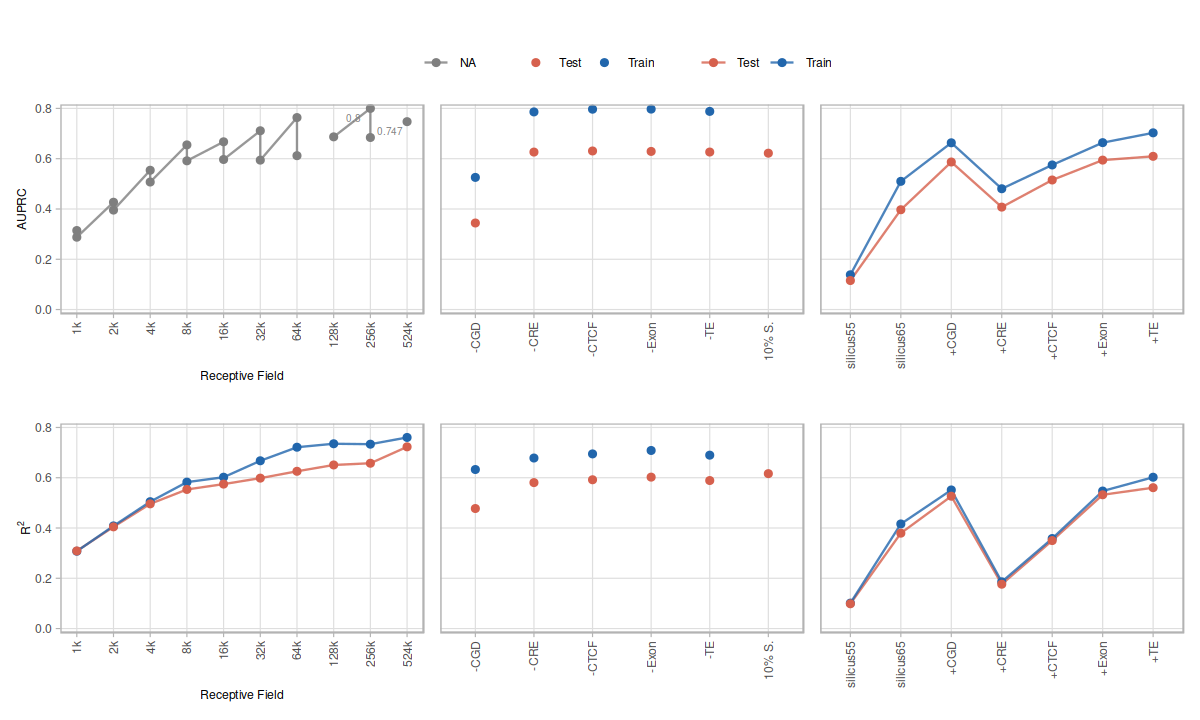

In [18]:
sps(10, 6)
combined_plot_mm10

## 14. Barplot Figure - Test Data Only with SNS Reference (Main Figure)

In [19]:
# --- Barplot: Test Data Only with SNS as a Bar in RF Series ---

# Get SNS reference values (test set)
sns_auprc_test <- if (!is.null(auprc_sns)) auprc_sns$auprc_test[auprc_sns$col_name == "sns_lm"] else NA
sns_rsqr_test <- if (!is.null(rsqr_sns)) rsqr_sns$r2_test[rsqr_sns$col_name == "sns_lm"] else NA

# --- 1. Prepare Data: Add SNS row to RF series ---

# Define new levels for RF (appending SNS at the end)
rf_levels_sns <- c(rf_values, "SNS")

# Add SNS row to Overlap Data
rf_auprc_mod <- auprc_rf_k27 %>% 
    # filter(series == "fm") %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf) %>%
    bind_rows(data.frame(
        # series = "fm", 
        series = "flashzoi",
        genome_label = "SNS", 
        auprc_test = sns_auprc_test
    ))

# Add SNS row to R2 Data
rf_rsqr_mod <- rsqr_rf_k27 %>% 
    # filter(series == "fm") %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf) %>%
    bind_rows(data.frame(
        # series = "fm", 
        series = "flashzoi",
        genome_label = "SNS", 
        r2_test = sns_rsqr_test
    ))

# Other series remain the same
mm10minus_auprc <- auprc_k27 %>% 
    filter(series == "mm10Minus") %>% 
    mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
    filter(!grepl("pad", genome_label))

mm10minus_rsqr <- rsqr_k27 %>% 
    filter(series == "mm10Minus") %>% 
    mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
    filter(!grepl("pad", genome_label))

telescope_auprc <- auprc_k27 %>% 
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

telescope_rsqr <- rsqr_k27 %>% 
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))


# --- 2. Helper Function with Bar Highlighting ---

plot_barplot_test <- function(data, value_col, y_label, sns_ref = NULL, 
                              x_levels = NULL, ylim = c(0, 0.8),
                              bar_color = "#2C7BB6", sns_color = "red",
                              highlight_bar = NULL, highlight_color = "#E31A1C", # New args
                              x_var = "genome_label",
                              show_sns_label = FALSE) {
    
    plot_data <- data
    if (!is.null(x_levels)) {
        plot_data <- plot_data %>%
            mutate(!!sym(x_var) := factor(.data[[x_var]], levels = x_levels))
    }
    
    # Base Plot
    p <- ggplot(plot_data, aes(x = .data[[x_var]], y = .data[[value_col]]))
    
    # Conditional Fill: Check if we need to highlight a specific bar (e.g., SNS)
    if (!is.null(highlight_bar)) {
        p <- p + geom_col(aes(fill = .data[[x_var]] == highlight_bar), 
                          alpha = 0.8, width = 0.7) +
                 scale_fill_manual(values = c("FALSE" = bar_color, "TRUE" = highlight_color), 
                                   guide = "none")
    } else {
        p <- p + geom_col(fill = bar_color, alpha = 0.8, width = 0.7)
    }

    # Labels and Theme
    p <- p + 
        geom_text(aes(label = round(.data[[value_col]], 2)), 
                  vjust = -0.2, 
                  size = 2) + 
        scale_y_continuous(limits = ylim, expand = expansion(mult = c(0, 0.1))) +
        labs(x = "", y = y_label) +
        tgppt::theme_arial(7) +
        vertical_labs() + # Preserves rotation
        theme(panel.grid.major.y = element_line(color = "gray93"),
              panel.grid.minor.y = element_blank())
    
    # Add SNS reference line (only if provided)
    if (!is.null(sns_ref)) {
        p <- p + 
            geom_hline(yintercept = sns_ref, linetype = "dashed", 
                       color = sns_color, linewidth = 0.8)
            
        if (show_sns_label) {
             p <- p + annotate("text", x = 1, y = sns_ref, # Put label near start
                     label = sprintf("SNS: %.2f", sns_ref),
                     hjust = 0, vjust = -1, size = 2.5, 
                     color = sns_color, fontface = "italic")
        }
    }
    
    return(p)
}


# --- 3. Create Plots ---

# Row 1: Overlap

# RF: Has SNS Bar, No Line
bar_auprc_rf <- plot_barplot_test(
    rf_auprc_mod, "auprc_test", "AUPRC",
    sns_ref = NULL, 
    x_levels = rf_levels_sns, # Use new levels with SNS
    ylim = common_ylim,
    highlight_bar = "SNS" # Highlight the SNS bar
) 

# mm10: No Bar
bar_auprc_minus <- plot_barplot_test(
    mm10minus_auprc, "auprc_test", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim,
    show_sns_label = TRUE # Label appears here now
) + clean_y_axis()

# Telescope
bar_auprc_tel <- plot_barplot_test(
    telescope_auprc, "auprc_test", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim,
    show_sns_label = FALSE
) + clean_y_axis()


# Row 2: R²

# RF: Has SNS Bar
bar_rsqr_rf <- plot_barplot_test(
    rf_rsqr_mod, "r2_test", expression(R^2),
    sns_ref = NULL,
    x_levels = rf_levels_sns,
    ylim = common_ylim_r2,
    highlight_bar = "SNS"
)

# mm10
bar_rsqr_minus <- plot_barplot_test(
    mm10minus_rsqr, "r2_test", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim_r2,
    show_sns_label = TRUE
) + clean_y_axis()

# Telescope: No Bar
bar_rsqr_tel <- plot_barplot_test(
    telescope_rsqr, "r2_test", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim_r2,
    show_sns_label = FALSE
) + clean_y_axis()


# --- 1. Remove X-axis labels from the Top Row (Overlap) ---
# We use element_blank() to remove both the text and the tick marks
theme_no_x <- theme(
  axis.text.x = element_blank(),
  axis.ticks.x = element_blank()
)

bar_auprc_rf    <- bar_auprc_rf + theme_no_x
bar_auprc_minus <- bar_auprc_minus + theme_no_x
bar_auprc_tel   <- bar_auprc_tel + theme_no_x

# --- 2. Combine and Save ---
barplot_combined <- wrap_plots(
    bar_auprc_rf, bar_auprc_minus, bar_auprc_tel,
    bar_rsqr_rf,    bar_rsqr_minus,    bar_rsqr_tel,
    ncol = 3, 
    widths = c(1, 1, 1) 
) +
plot_layout(axis_titles = "collect") &
theme(plot.margin = margin(10, 10, 5, 5))

# Export
ppt_path_bar <- here("figures/k27_barplot_test_only_v3.pptx")
tgppt::plot_base_ppt(print(barplot_combined), ppt_path_bar, width = 18, height = 8, overwrite = TRUE)

message("Barplot figure saved to ", ppt_path_bar)

Barplot figure saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_barplot_test_only_v3.pptx



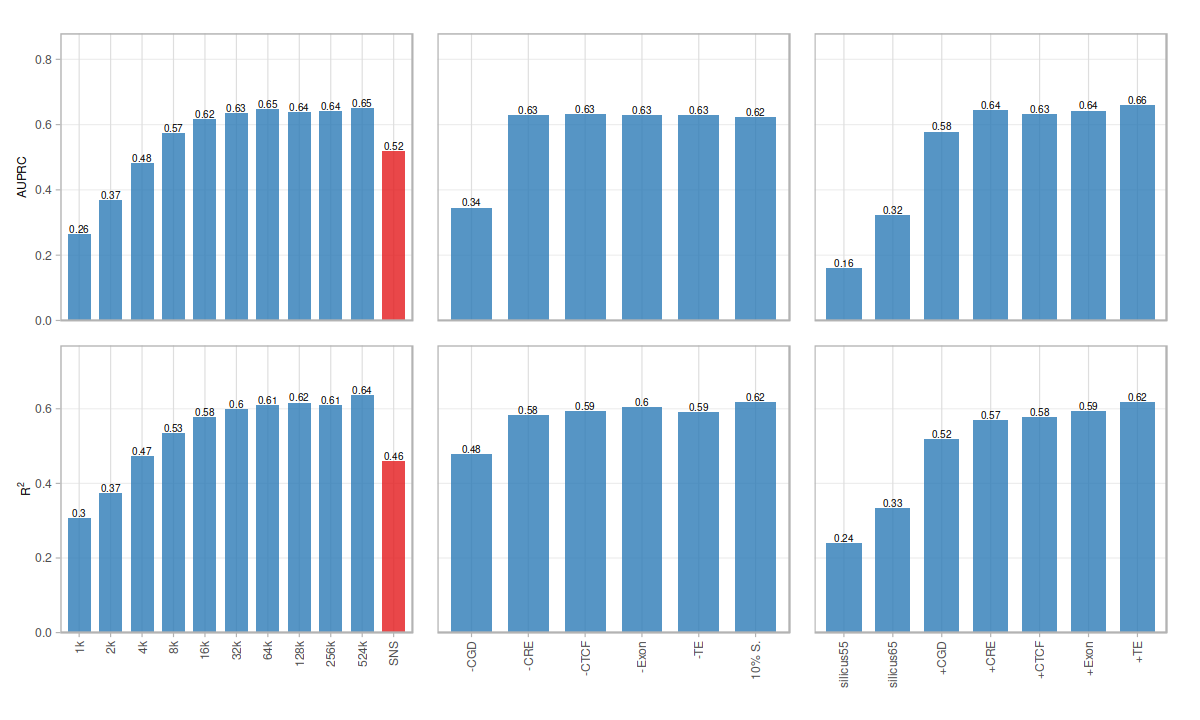

In [20]:
sps(10, 6)
barplot_combined

K4 Barplot figure saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k4_barplot_test_only.pptx



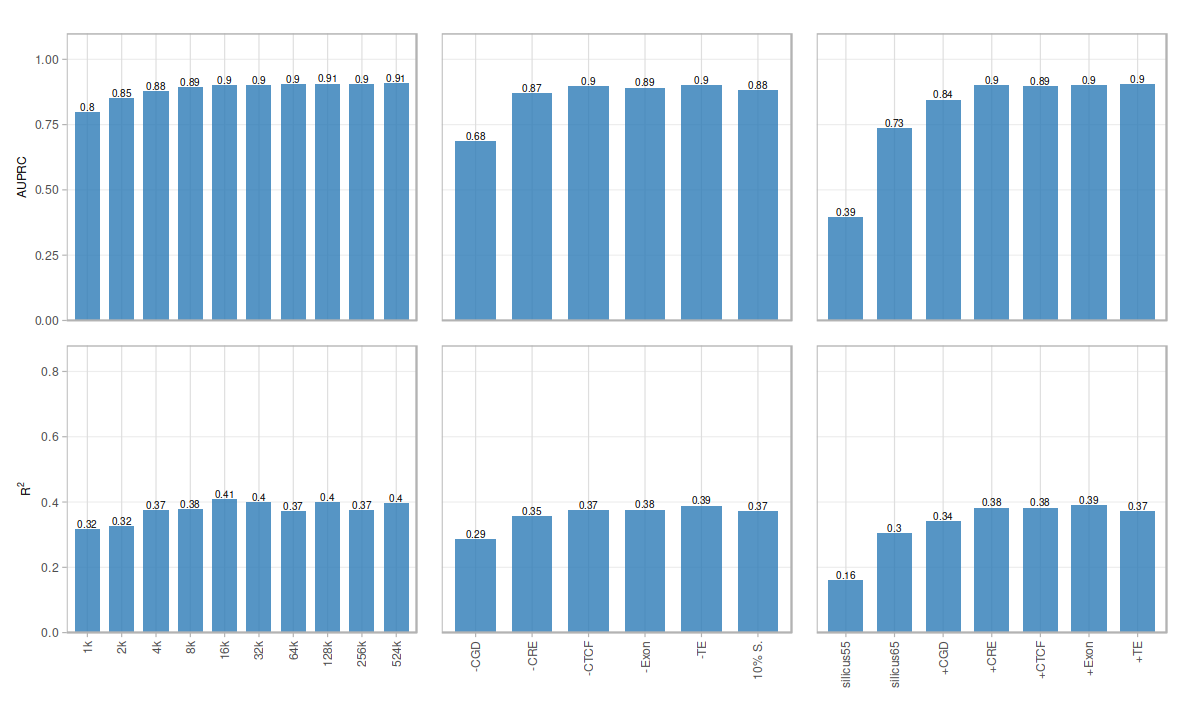

In [21]:
# ==============================================================================
# Barplot Combined - K4 (Supplementary Figure)
# ==============================================================================

# --- 1. Prepare K4 Data ---
common_ylim_k4 <- c(0, 1)
common_ylim_k4_r2 <- c(0, 0.8)

# Get SNS reference values for K4 (if available - SNS is K27 only, so likely NA)
sns_auprc_test_k4 <- NA
sns_rsqr_test_k4 <- NA

# RF series (K4)
rf_auprc_k4_mod <- auprc_rf_k4 %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf)

rf_rsqr_k4_mod <- rsqr_rf_k4 %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf)

# mm10Minus series (K4)
mm10minus_auprc_k4 <- auprc_k4 %>%
    filter(series == "mm10Minus") %>%
    mutate(genome_label = gsub("mm10", "", genome_label)) %>%
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>%
    filter(!grepl("pad", genome_label))

mm10minus_rsqr_k4 <- rsqr_k4 %>%
    filter(series == "mm10Minus") %>%
    mutate(genome_label = gsub("mm10", "", genome_label)) %>%
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>%
    filter(!grepl("pad", genome_label))

# Telescope series (K4)
telescope_auprc_k4 <- auprc_k4 %>%
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

telescope_rsqr_k4 <- rsqr_k4 %>%
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

# --- 2. Create K4 Barplots ---

# Row 1: AUPRC

bar_auprc_rf_k4 <- plot_barplot_test(
    rf_auprc_k4_mod, "auprc_test", "AUPRC",
    sns_ref = NULL,
    x_levels = rf_values,
    ylim = common_ylim_k4
) + theme_no_x

bar_auprc_minus_k4 <- plot_barplot_test(
    mm10minus_auprc_k4, "auprc_test", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim_k4
) + clean_y_axis() + theme_no_x

bar_auprc_tel_k4 <- plot_barplot_test(
    telescope_auprc_k4, "auprc_test", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim_k4
) + clean_y_axis() + theme_no_x

# Row 2: R²

bar_rsqr_rf_k4 <- plot_barplot_test(
    rf_rsqr_k4_mod, "r2_test", expression(R^2),
    sns_ref = NULL,
    x_levels = rf_values,
    ylim = common_ylim_k4_r2
)

bar_rsqr_minus_k4 <- plot_barplot_test(
    mm10minus_rsqr_k4, "r2_test", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim_k4_r2
) + clean_y_axis()

bar_rsqr_tel_k4 <- plot_barplot_test(
    telescope_rsqr_k4, "r2_test", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim_k4_r2
) + clean_y_axis()

# --- 3. Combine and Export ---

barplot_combined_k4 <- wrap_plots(
    bar_auprc_rf_k4, bar_auprc_minus_k4, bar_auprc_tel_k4,
    bar_rsqr_rf_k4, bar_rsqr_minus_k4, bar_rsqr_tel_k4,
    ncol = 3,
    widths = c(1, 1, 1)
) +
plot_layout(axis_titles = "collect") &
theme(plot.margin = margin(10, 10, 5, 5))

# Export
ppt_path_bar_k4 <- here("figures/k4_barplot_test_only.pptx")
tgppt::plot_base_ppt(print(barplot_combined_k4), ppt_path_bar_k4, width = 18, height = 10, overwrite = TRUE)

message("K4 Barplot figure saved to ", ppt_path_bar_k4)

sps(10, 6)
barplot_combined_k4


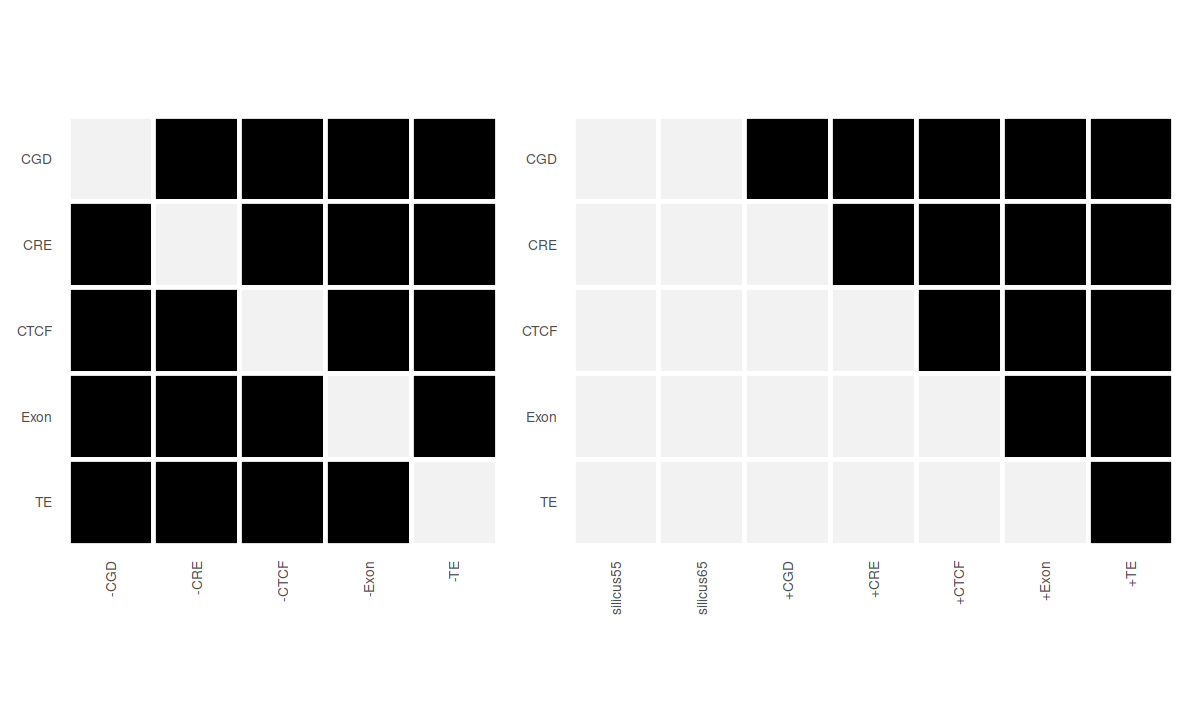

In [22]:
library(tidyverse)
library(patchwork)

# --- 1. Define Elements and Order ---
elements <- c("CGD", "CRE", "CTCF", "Exon", "TE")

# --- 2. Create Data for "Minus" Series ---
minus_cols <- c("-CGD", "-CRE", "-CTCF", "-Exon", "-TE")

df_minus <- expand.grid(Element = elements, Genome = minus_cols) %>%
  mutate(
    Present = ifelse(Element == gsub("-", "", Genome), 0, 1),
    Element = factor(Element, levels = rev(elements)),
    Genome = factor(Genome, levels = minus_cols)
  )

# --- 3. Create Data for "Telescope" Series ---
tel_cols <- c("silicus55", "silicus65", "+CGD", "+CRE", "+CTCF", "+Exon", "+TE")

get_cumulative_presence <- function(elem, gen) {
  if (gen == "silicus55") return(0)
  add_order <- c("silicus65", "CGD", "CRE", "CTCF", "Exon", "TE")
  
  elem_idx <- which(add_order == elem)
  gen_clean <- gsub("\\+", "", gen)
  gen_idx <- which(add_order == gen_clean)
  
  ifelse(elem_idx <= gen_idx, 1, 0)
}

df_tel <- expand.grid(Element = elements, Genome = tel_cols) %>%
  rowwise() %>%
  mutate(
    Present = get_cumulative_presence(Element, Genome)
  ) %>%
  ungroup() %>%
  mutate(
    Element = factor(Element, levels = rev(elements)),
    Genome = factor(Genome, levels = tel_cols)
  )

# --- 4. Plotting Function (Updated) ---
plot_structure_heatmap <- function(data) {
  ggplot(data, aes(x = Genome, y = Element, fill = as.factor(Present))) +
    # CHANGE: color = "white" ensures lines are visible against black background
    geom_tile(color = "white", linewidth = 1) + 
    scale_fill_manual(values = c("0" = "gray95", "1" = "black")) + # Optional: use gray95 for white to see borders better
    coord_fixed() +
    labs(x = NULL, y = NULL) +
    theme_minimal(base_size = 10) +
    theme(
      legend.position = "none",
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
      panel.grid = element_blank(),
      axis.ticks = element_blank()
    )
}

# --- 5. Generate and Combine ---
p_struct_minus <- plot_structure_heatmap(df_minus)
p_struct_tel   <- plot_structure_heatmap(df_tel)

# Combine side-by-side
p_structure_combined <- p_struct_minus + p_struct_tel

tgppt::plot_base_ppt(print(p_structure_combined), here("figures/k27_structure_heatmap.pptx"), width = 18, height = 6, overwrite = TRUE)

print(p_structure_combined)

## 15. Barplot with silicusTelescopeMm10 (Main Figure Variant)

In [23]:
# --- Barplot with silicusTelescopeMm10 variant ---
# Layout: 3 columns (RF | mm10Minus | TelescopeMm10), 2 rows (Overlap | R²)

# Telescope Mm10 series
telescope_mm10_auprc <- auprc_k27 %>% 
    filter(series == "silicusTelescopeMm10") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

telescope_mm10_rsqr <- rsqr_k27 %>% 
    filter(series == "silicusTelescopeMm10") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

# Barplot: Telescope Mm10 Overlap (test)
bar_auprc_tel_mm10 <- plot_barplot_test(
    telescope_mm10_auprc, "auprc_test", "",
    sns_ref = NA,
    x_levels = tel_short_levels,
    ylim = common_ylim
) + clean_y_axis() + theme_no_x

# Barplot: Telescope Mm10 R² (test)
bar_rsqr_tel_mm10 <- plot_barplot_test(
    telescope_mm10_rsqr, "r2_test", "",
    sns_ref = NA,
    x_levels = tel_short_levels,
    ylim = common_ylim_r2
) + clean_y_axis()

barplot_combined_mm10 <- wrap_plots(
    bar_auprc_rf, bar_auprc_minus, bar_auprc_tel_mm10,
    bar_rsqr_rf,    bar_rsqr_minus,    bar_rsqr_tel_mm10,
    ncol = 3, 
    widths = c(1.5, 1, 1) # This now correctly sets the column ratios
) +
plot_layout(axis_titles = "collect") &
theme(plot.margin = margin(10, 10, 5, 5))

# Export barplot figure
ppt_path_bar_mm10 <- here("figures/k27_barplot_test_only_mm10_telescope.pptx")
tgppt::plot_base_ppt(print(barplot_combined_mm10), ppt_path_bar_mm10, width = 18, height = 10, overwrite = TRUE)

message("Barplot figure with silicusTelescopeMm10 saved to ", ppt_path_bar_mm10)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Barplot figure with silicusTelescopeMm10 saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_barplot_test_only_mm10_telescope.pptx



Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”


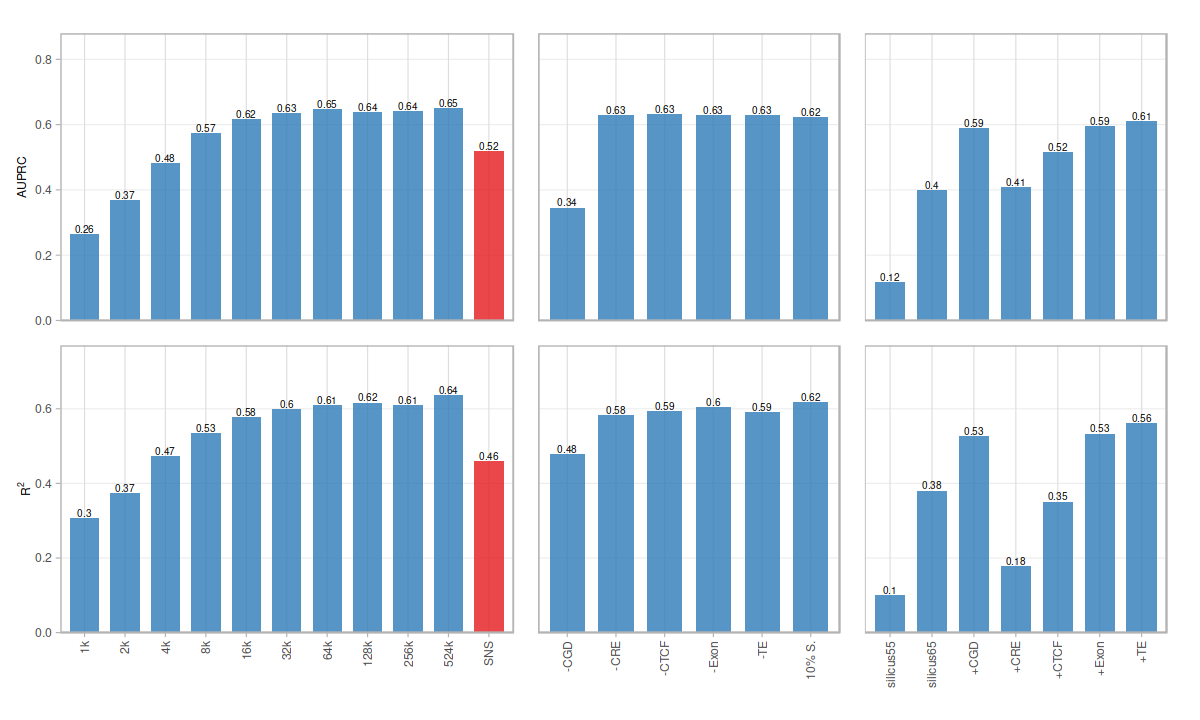

In [24]:
sps(10, 6)
barplot_combined_mm10

## Foundation Model (FM)

In [25]:
# --- 2. Combine AUPRC and R2 for both series ---

# Combine AUPRC results using FM vs Pretrain intervals (train_mod_gw and val_mod_gw)
# Using auprc_rf_k27_fm which was computed with train_mod_gw as train and val_mod_gw as test
compare_auprc <- bind_rows(
    auprc_rf_k27_fm_results %>% filter(series == "flashzoi") %>% select(rf, rf_numeric, series, auprc_train, auprc_test),
    auprc_rf_k27_fm_results %>% filter(series == "fm") %>% select(rf, rf_numeric, series, auprc_train, auprc_test)
) %>%
    pivot_longer(cols = c(auprc_train, auprc_test), names_to = "split", values_to = "value") %>%
    mutate(split = gsub("auprc_", "", split),
           series = factor(series, levels = c("flashzoi", "fm"), labels = c("Pretrain", "Foundation")))

# Combine R2 results using FM vs Pretrain intervals (train_mod_gw and val_mod_gw)
# Using rsqr_rf_k27_fm which was computed with train_mod_gw as train and val_mod_gw as test
compare_rsqr <- bind_rows(
    rsqr_rf_k27_fm %>% filter(series == "flashzoi") %>% select(rf, rf_numeric, series, r2_train, r2_test),
    rsqr_rf_k27_fm %>% filter(series == "fm") %>% select(rf, rf_numeric, series, r2_train, r2_test)
) %>%
    pivot_longer(cols = c(r2_train, r2_test), names_to = "split", values_to = "value") %>%
    mutate(split = gsub("r2_", "", split),
           series = factor(series, levels = c("flashzoi", "fm"), labels = c("Pretrain", "Foundation")))

Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_text()`).

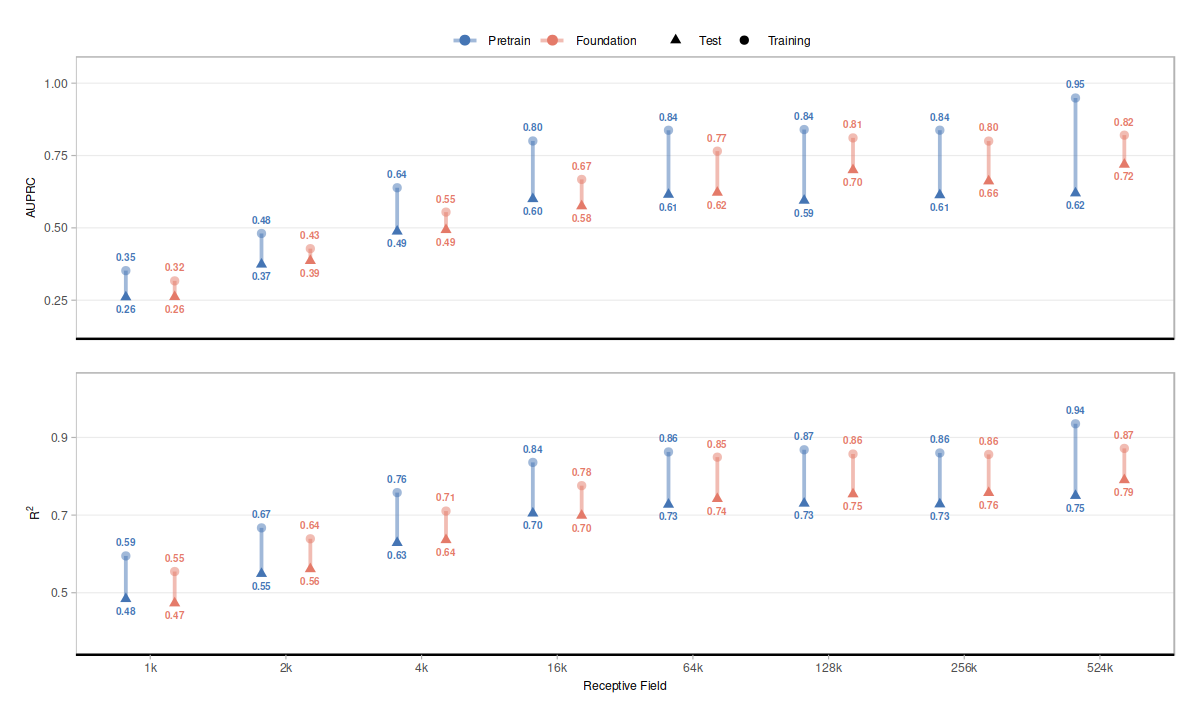

In [26]:
plot_comparison <- function(df, y_lab) {
    # Calculate positions
    df <- df %>%
        mutate(
            rf_idx = match(rf_numeric, CONFIG$rf_numeric),
            x_pos = rf_idx + ifelse(series == "Pretrain", -0.18, 0.18)
        )

    ggplot(df, aes(x = x_pos, y = value, color = series, group = interaction(rf_idx, series))) +
        
        # 1. The Bridge Line (Coloured by series, slightly transparent)
        geom_line(linewidth = 0.8, alpha = 0.5) +
        
        # 2. The Points
        # Map alpha to split to emphasize TEST (Triangle) over TRAIN (Circle)
        geom_point(aes(shape = split, alpha = split), size = 2, stroke = 0.5) +
        
        # 3. Dynamic Labels (Train UP, Test DOWN)
        geom_text(aes(label = sprintf("%.2f", value), 
                      vjust = ifelse(split == "train", -1.2, 2.0)), 
                  size = 2, # Slightly smaller to accommodate double the labels
                  fontface = "bold", 
                  show.legend = FALSE) +
        
        # Scales
        scale_x_continuous(breaks = seq_along(CONFIG$rf_values), 
                           labels = CONFIG$rf_values) +
        
        # Colors aligned to barplot
        scale_color_manual(values = c("Pretrain" = "#4575B4", "Foundation" = "#E47A69")) +
        
        scale_shape_manual(values = c(train = 16, test = 17),
                           labels = c(train = "Training", test = "Test")) +
        
        # Alpha scale
        scale_alpha_manual(values = c(train = 0.5, test = 1.0), guide = "none") +
        
        # Aesthetics
        labs(x = "Receptive Field", y = y_lab,
             color = "", shape = "") +
        tgppt::theme_arial(7) + 
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(color = "gray92"),
            panel.grid.minor.y = element_blank(),
            axis.line.x = element_line(color = "black"),
            legend.position = "top",
            legend.margin = margin(b = -10),
            plot.title = element_text(face = "bold", size = 11),
            plot.margin = margin(10, 10, 10, 10)
        ) +
        # IMPORTANT: Increased expansion to prevent top labels from being cut off
        expand_limits(y = c(min(df$value) - 0.1, max(df$value) + 0.1))
}

# Generate plots
p_comp_auprc <- plot_comparison(compare_auprc, "AUPRC") + theme_no_x
p_comp_rsqr  <- plot_comparison(compare_rsqr, expression(R^2)) 
# Combine
comparison_final <- (p_comp_auprc / p_comp_rsqr) + 
    plot_layout(guides = "collect", axis_titles = "collect") & 
    theme(legend.position = "top", legend.box = "horizontal")

tgppt::plot_base_ppt(print(comparison_final), 
                     here("figures/fm_vs_pretrain_comparison.pptx"), 
                     width = 12, height = 10, overwrite = TRUE)

print(comparison_final)

In [27]:
  build_silicusPlus_telescope_comparison_track_table <- function() {
      # FM directory naming for silicusPlus telescope
      genome_configs <- tribble(
          ~genome_dir, ~genome_label, ~order,
          "silicus", "silicus", 1,
          "silicusPlusCGDCtcf", "+CTCF", 2,
          "silicusPlusCGDCtcfCre", "+CRE", 3,
          "silicusPlusCGDCtcfCreExon", "+Exon", 4,
          "silicusPlusCGDCtcfCreExonTE", "+TE", 5
        #   "silicusPlusCGDCtcfCreExonTEUtr3", "+Utr3", 6
      )

      # FM K27 tracks
      fm_k27 <- genome_configs %>%
          mutate(
              series = "fm",
              track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_EB4_cnt"),
              col_name = paste0("fm_", genome_dir, "_k27"),
              mark = "K27"
          )

      # FM K4 tracks
      fm_k4 <- genome_configs %>%
          mutate(
              series = "fm",
              track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_EB4_cnt_k4"),
              col_name = paste0("fm_", genome_dir, "_k4"),
              mark = "K4"
          )

      # Flashzoi (Pretrain) - need to map to flashzoi track naming
      # flashzoi uses silicusPlusCGD* naming pattern
      flashzoi_genome_configs <- tribble(
          ~genome_dir, ~genome_label, ~order,
          "silicus", "silicus", 1,
          "silicusPlusCGDCreCtcf", "+CTCF", 2,  # Note: flashzoi naming differs
          "silicusPlusCGDCre", "+CRE", 3,
          "silicusPlusCGDCreCtcfExon", "+Exon", 4,
          "silicusPlusCGDCreCtcfExonTE", "+TE", 5
      )

      # Flashzoi K27 tracks (using ft_ prefix for finetuned tracks)
      flashzoi_k27 <- flashzoi_genome_configs %>%
          mutate(
              series = "flashzoi",
              track_name = paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
              col_name = paste0("flashzoi_", genome_dir, "_k27"),
              mark = "K27"
          )

      # Flashzoi K4 tracks
      flashzoi_k4 <- flashzoi_genome_configs %>%
          mutate(
              series = "flashzoi",
              track_name = paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
              col_name = paste0("flashzoi_", genome_dir, "_k4"),
              mark = "K4"
          )

      return(bind_rows(fm_k27, fm_k4, flashzoi_k27, flashzoi_k4))
  }

  silicusPlus_tel_track_tbl <- build_silicusPlus_telescope_comparison_track_table()

  # Verify tracks exist
  missing_tracks <- silicusPlus_tel_track_tbl$track_name[!sapply(silicusPlus_tel_track_tbl$track_name, gtrack.exists)]
  if (length(missing_tracks) > 0) {
      message("WARNING: Missing tracks:")
      print(unique(missing_tracks))
  } else {
      message(sprintf("All %d silicusPlus telescope tracks found!", nrow(silicusPlus_tel_track_tbl)))
  }


All 20 silicusPlus telescope tracks found!



In [28]:
  silicusPlus_tel_k27_tracks <- silicusPlus_tel_track_tbl %>% filter(mark == "K27")

  message("Computing AUPRC for silicusPlus telescope K27 tracks...")
  doMC::registerDoMC(cores = 50)

  auprc_silicusPlus_tel_k27_results <- plyr::adply(silicusPlus_tel_k27_tracks, 1, function(row) {
      tryCatch({
          metrics <- compute_track_auprc_custom(
              track_name = row$track_name,
              obs_track_name = CONFIG$obs_k27_track,
              intervals_train = intervals_train_fm,
              intervals_test = intervals_test_fm,
              T_q = CONFIG$T_q,
              context_size = CONFIG$context_size,
              iterator_size = CONFIG$iterator_size
          )
          data.frame(
              col_name = row$col_name,
              genome_label = row$genome_label,
              order = row$order,
              series = row$series,
              auprc_train = metrics["auprc_train"],
              auprc_test = metrics["auprc_test"]
          )
      }, error = function(e) {
          message(sprintf("  ERROR processing %s: %s", row$col_name, e$message))
          data.frame(col_name = row$col_name, genome_label = row$genome_label,
                     order = row$order, series = row$series, auprc_train = NA, auprc_test = NA)
      })
  }, .parallel = TRUE) %cache_rds% here("output/borzoi-stats/auprc-silicusPlus-tel-comparison-k27.rds")


Computing AUPRC for silicusPlus telescope K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/auprc-silicusPlus-tel-comparison-k27.rds'



In [29]:
compute_silicusPlus_tel_r2_metrics <- function(track_tbl, intervals_train, intervals_test, obs_k27_expr) {
    k27_info <- track_tbl %>% filter(mark == "K27")

    intervals_all <- bind_rows(
        intervals_train %>% select(chrom, start, end),
        intervals_test %>% select(chrom, start, end)
    )

    purrr::walk2(k27_info$track_name, k27_info$col_name,
                ~gvtrack.create(.y, .x, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size))

    r2_data <- gextract(c(k27_info$col_name, obs_k27_expr),
                        intervals = intervals_all,
                        iterator = CONFIG$iterator_size,
                        colnames = c(k27_info$col_name, "obs_k27"))

    intervals_train_clean <- intervals_train %>% select(chrom, start, end)
    intervals_test_clean <- intervals_test %>% select(chrom, start, end)

    train_mat <- r2_data %>%
        gintervals.neighbors(intervals_train_clean) %>%
        filter(dist == 0) %>%
        select(-dist, -chrom1, -start1, -end1) %>%
        select(all_of(c(k27_info$col_name, "obs_k27"))) %>%
        as.matrix()

    test_mat <- r2_data %>%
        gintervals.neighbors(intervals_test_clean) %>%
        filter(dist == 0) %>%
        select(-dist, -chrom1, -start1, -end1) %>%
        select(all_of(c(k27_info$col_name, "obs_k27"))) %>%
        as.matrix()

    train_r2 <- tgs_cor(train_mat[, -ncol(train_mat)],
                        as.matrix(train_mat[, ncol(train_mat)]),
                        pairwise.complete.obs = TRUE, tidy = TRUE) %>%
        select(col_name = col1, r2_train = cor)

    test_r2 <- tgs_cor(test_mat[, -ncol(test_mat)],
                        as.matrix(test_mat[, ncol(test_mat)]),
                        pairwise.complete.obs = TRUE, tidy = TRUE) %>%
        select(col_name = col1, r2_test = cor)

    rsqr <- left_join(train_r2, test_r2, by = "col_name") %>%
        mutate(r2_train = r2_train^2, r2_test = r2_test^2) %>%
        left_join(k27_info %>% select(col_name, genome_label, order, series), by = "col_name")

    return(rsqr)
}

message("Computing R² for silicusPlus telescope K27 tracks...")
rsqr_silicusPlus_tel_k27 <- compute_silicusPlus_tel_r2_metrics(
    silicusPlus_tel_track_tbl,
    intervals_train_fm,
    intervals_test_fm,
    obs_k27_expr
) %cache_rds% here("output/borzoi-stats/rsqr-silicusPlus-tel-comparison-k27.rds")


Computing R² for silicusPlus telescope K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-silicusPlus-tel-comparison-k27.rds'



In [30]:
# silicus_tel_levels <- c("silicus", "+CGD", "+CRE", "+Exon", "+TE", "+Utr3")
silicus_tel_levels <- c("silicus", "+CGD", "+CRE", "+Exon", "+TE")

compare_silicus_tel_auprc <- auprc_silicusPlus_tel_k27_results %>%
    select(genome_label, order, series, auprc_train, auprc_test) %>%
    pivot_longer(cols = c(auprc_train, auprc_test), names_to = "split", values_to = "value") %>%
    mutate(split = gsub("auprc_", "", split),
            series = factor(series, levels = c("flashzoi", "fm"), labels = c("Pretrain", "Foundation"))) 

compare_silicus_tel_rsqr <- rsqr_silicusPlus_tel_k27 %>%
    select(genome_label, order, series, r2_train, r2_test) %>%
    pivot_longer(cols = c(r2_train, r2_test), names_to = "split", values_to = "value") %>%
    mutate(split = gsub("r2_", "", split),
            series = factor(series, levels = c("flashzoi", "fm"), labels = c("Pretrain", "Foundation")))


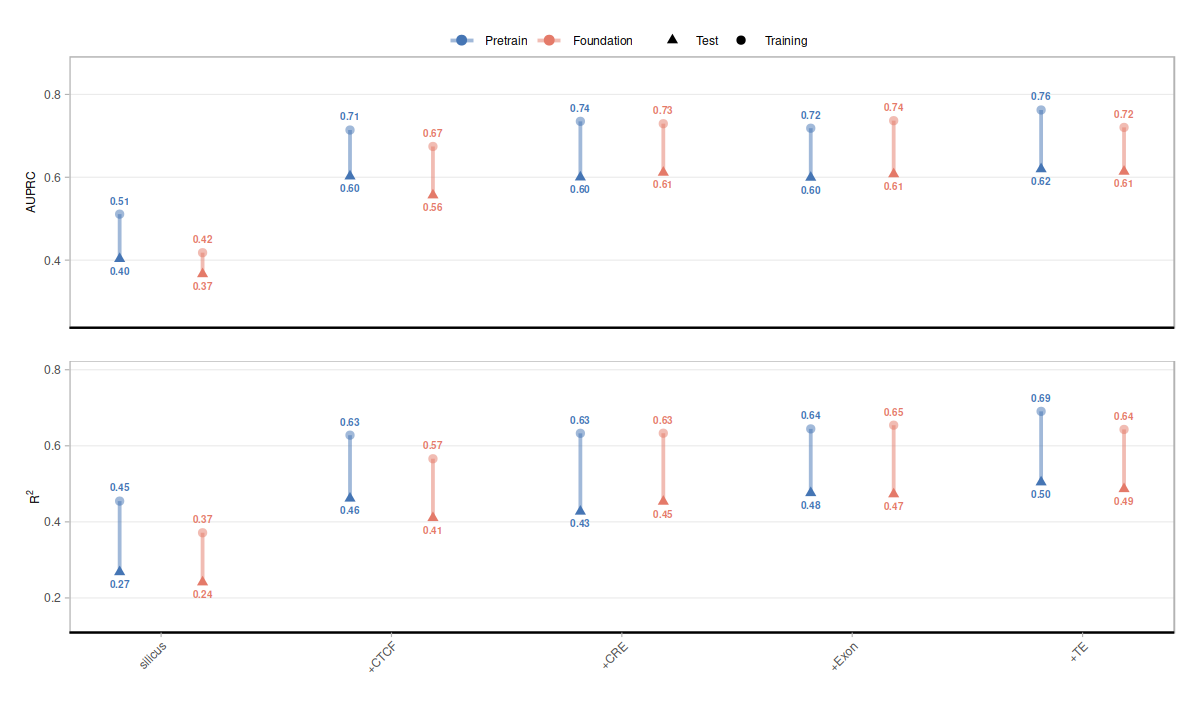

In [31]:
plot_silicus_tel_comparison <- function(df, y_lab) {
    # Remove "UTR3" if present
    df <- df %>% filter(genome_label != "+Utr3")

    # Calculate positions (like plot_comparison with rf_idx)
    df <- df %>%
        mutate(
            x_idx = order,
            x_pos = x_idx + ifelse(series == "Pretrain", -0.18, 0.18)
        )

    # Get unique labels for x-axis, omitting anything containing "UTR3"
    x_labels <- df %>%
        distinct(order, genome_label) %>%
        arrange(order) %>%
        pull(genome_label)

    ggplot(df, aes(x = x_pos, y = value, color = series, group = interaction(x_idx, series))) +

        # 1. The Bridge Line
        geom_line(linewidth = 0.8, alpha = 0.5) +

        # 2. The Points
        geom_point(aes(shape = split, alpha = split), size = 2, stroke = 0.5) +

        # 3. Dynamic Labels (Train UP, Test DOWN)
        geom_text(aes(label = sprintf("%.2f", value),
                    vjust = ifelse(split == "train", -1.2, 2.0)),
                size = 2,
                fontface = "bold",
                show.legend = FALSE) +

        # Scales
        scale_x_continuous(breaks = seq_along(x_labels),
                            labels = x_labels) +

        # Colors aligned to comparison_final
        scale_color_manual(values = c("Pretrain" = "#4575B4", "Foundation" = "#E47A69")) +

        scale_shape_manual(values = c(train = 16, test = 17),
                            labels = c(train = "Training", test = "Test")) +

        scale_alpha_manual(values = c(train = 0.5, test = 1.0), guide = "none") +

        # Aesthetics
        labs(x = "", y = y_lab, color = "", shape = "") +
        tgppt::theme_arial(7) +
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(color = "gray92"),
            panel.grid.minor.y = element_blank(),
            axis.line.x = element_line(color = "black"),
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "top",
            legend.margin = margin(b = -10),
            plot.title = element_text(face = "bold", size = 11),
            plot.margin = margin(10, 10, 10, 10)
        ) +
        expand_limits(y = c(min(df$value, na.rm = TRUE) - 0.1, max(df$value, na.rm = TRUE) + 0.1))
}

# --- 6. Generate final plot ---

p_silicus_tel_auprc <- plot_silicus_tel_comparison(compare_silicus_tel_auprc, "AUPRC") + theme_no_x
p_silicus_tel_rsqr <- plot_silicus_tel_comparison(compare_silicus_tel_rsqr, expression(R^2))

silicus_tel_comparison_final <- (p_silicus_tel_auprc / p_silicus_tel_rsqr) +
    plot_layout(guides = "collect", axis_titles = "collect") &
    theme(legend.position = "top", legend.box = "horizontal")

tgppt::plot_base_ppt(print(silicus_tel_comparison_final),
                    here("figures/silicus_tel_comparison_final.pptx"),
                    width = 7, height = 10, overwrite = TRUE)

print(silicus_tel_comparison_final)


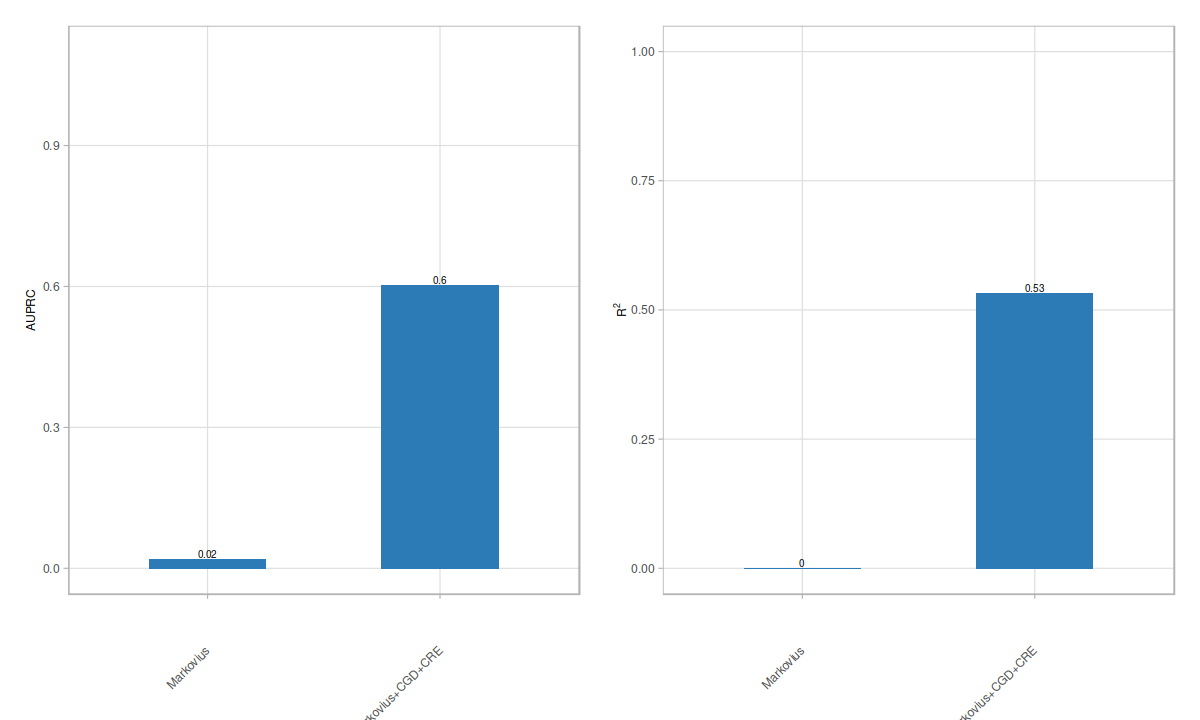

In [32]:

# --- 7. Markovius series: side-by-side AUPRC/R2 plots ---

# comparison_final is a plot; use auprc_k27 and rsqr_k27 for Markovius data
markovius_labels <- c("Markovius", "Markovius+CGD+CRE")

auprc_markovius <- auprc_k27 %>%
    filter(series == "markovius") %>%
    mutate(
        series = factor(
            ifelse(genome_label == "markovius", "Markovius", "Markovius+CGD+CRE"),
            levels = markovius_labels
        ),
        value = auprc_test
    ) %>%
    select(series, value)

rsqr_markovius <- rsqr_k27 %>%
    filter(series == "markovius") %>%
    mutate(
        series = factor(
            ifelse(genome_label == "markovius", "Markovius", "Markovius+CGD+CRE"),
            levels = markovius_labels
        ),
        value = r2_test
    ) %>%
    select(series, value)

# Define colors
markovius_colors <- c("Markovius" = "#2C7BB6", "Markovius+CGD+CRE" = "#2C7BB6")

# Plot for AUPRC
p_markovius_auprc <- ggplot(auprc_markovius, aes(x = series, y = value, fill = series)) +
    geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.5) +
    geom_text(aes(label = round(value, 2)), vjust = -0.2, size = 2) +
    scale_fill_manual(values = markovius_colors) +
    labs(x = "", y = "AUPRC", fill = "") +
    tgppt::theme_arial(7) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 0.5),
        legend.position = "none",
        axis.title.x = element_blank(),
        plot.title = element_text(face = "bold", size = 11),
        plot.margin = margin(10, 10, 10, 10)
    ) +
    guides(fill = "none") +
    expand_limits(y = c(0, 1.1))

# Plot for R^2
p_markovius_rsqr <- ggplot(rsqr_markovius, aes(x = series, y = value, fill = series)) +
    geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.5) +
    scale_fill_manual(values = markovius_colors) +
    geom_text(aes(label = round(value, 2)), vjust = -0.2, size = 2) +
    labs(x = "", y = expression(R^2), fill = "") +
    tgppt::theme_arial(7) +
    theme(        
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 0.5),
        legend.position = "none",
        axis.title.x = element_blank(),
        plot.title = element_text(face = "bold", size = 11),
        plot.margin = margin(10, 10, 10, 10)
    ) +
    guides(fill = "none") +
    expand_limits(y = c(0, 1))

# Combine the two plots side by side
markovius_comparison_plot <- p_markovius_auprc + p_markovius_rsqr +
    plot_layout(ncol = 2, guides = "collect") &
    theme(legend.position = "top", legend.box = "horizontal")

tgppt::plot_base_ppt(print(markovius_comparison_plot),
    here("figures/markovius_comparison_side_by_side.pptx"),
    width = 7, height = 7, overwrite = TRUE)

print(markovius_comparison_plot)




In [33]:
browser()

Called from: eval(expr, envir)


In [ ]:
browser()

## Ensemble AUPRC: Borzoi rf524k + SNS linear model

In [36]:
# # Ensemble AUPRC: Borzoi rf524k + SNS linear model
# library(glmnet)
# library(PRROC)

# message("Extracting track values for ensemble...")

# # Create virtual tracks with context
# gvtrack.create("flash524k", "seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt", func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size)
# gvtrack.create("sns_lm", CONFIG$sns_lm_track, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size)
# gvtrack.create("obs_k27", CONFIG$obs_k27_track, func = "avg", sshift = -CONFIG$context_size, eshift = CONFIG$context_size)

# # Extract data
# ensemble_data <- gextract(c("flash524k", "sns_lm", "obs_k27"),
#                             iterator = CONFIG$iterator_size,
#                             intervals = intervals_all) %>%
#       filter(!chrom %in% c("chrX")) %>%
#       mutate(
#           # Replace NaN/NA with 0 (matching borzoi_utils.R behavior)
#           flash524k = ifelse(is.nan(flash524k) | is.na(flash524k), 0, flash524k),
#           sns_lm = ifelse(is.nan(sns_lm) | is.na(sns_lm), 0, sns_lm),
#           obs_k27 = ifelse(is.nan(obs_k27) | is.na(obs_k27), 0, obs_k27),
#           split = case_when(
#               chrom %in% test_chroms ~ "test",
#               chrom %in% val_chroms ~ "val",
#               TRUE ~ "train"
#           )
#       )

# # Cleanup virtual tracks
# gvtrack.rm("flash524k")
# gvtrack.rm("sns_lm")
# gvtrack.rm("obs_k27")

# # Define threshold for positives (top 2% of observed)
# q_obs <- quantile(ensemble_data$obs_k27, CONFIG$q_obs, na.rm = TRUE)
# ensemble_data$label <- as.integer(ensemble_data$obs_k27 > q_obs)

# # Split data
# train_data <- ensemble_data %>% filter(split == "train")
# test_data <- ensemble_data %>% filter(split == "test")
# val_data <- ensemble_data %>% filter(split == "val")

# # --- Fit ensemble model on train set ---
# message("Fitting glmnet ensemble on training data...")

# X_train <- as.matrix(train_data[, c("flash524k", "sns_lm")])
# y_train <- train_data$obs_k27

# # Use ridge regression (alpha=0) or elastic net
# cv_fit <- cv.glmnet(X_train, y_train, alpha = 0.5, nfolds = 5)
# best_lambda <- cv_fit$lambda.min

# message(sprintf("Best lambda: %g", best_lambda))

# # --- Generate predictions for all splits ---
# X_test <- as.matrix(test_data[, c("flash524k", "sns_lm")])
# X_val <- as.matrix(val_data[, c("flash524k", "sns_lm")])

# train_data$pred_ensemble <- as.vector(predict(cv_fit, X_train, s = best_lambda))
# test_data$pred_ensemble <- as.vector(predict(cv_fit, X_test, s = best_lambda))
# val_data$pred_ensemble <- as.vector(predict(cv_fit, X_val, s = best_lambda))

# # --- Compute AUPRC ---
# calc_auprc <- function(data) {
#     labels <- data$label
#     preds <- data$pred_ensemble

#     if (sum(labels == 1) == 0 || sum(labels == 0) == 0) {
#         return(NA)
#     }

#     pr <- PRROC::pr.curve(
#         scores.class0 = preds[labels == 1],
#         scores.class1 = preds[labels == 0]
#     )
#     return(pr$auc.integral)
# }

# auprc_ensemble <- c(
#     auprc_train = calc_auprc(train_data),
#     auprc_test = calc_auprc(test_data),
#     auprc_val = calc_auprc(val_data)
# )

# # --- Compare with individual models ---
# calc_auprc_direct <- function(data, pred_col) {
#     labels <- data$label
#     preds <- data[[pred_col]]

#     if (sum(labels == 1) == 0 || sum(labels == 0) == 0) {
#         return(NA)
#     }

#     pr <- PRROC::pr.curve(
#         scores.class0 = preds[labels == 1],
#         scores.class1 = preds[labels == 0]
#     )
#     return(pr$auc.integral)
# }

# # Compute AUPRC for individual predictors
# auprc_flash524k <- c(
#     auprc_train = calc_auprc_direct(train_data, "flash524k"),
#     auprc_test = calc_auprc_direct(test_data, "flash524k"),
#     auprc_val = calc_auprc_direct(val_data, "flash524k")
# )

# auprc_sns_lm <- c(
#     auprc_train = calc_auprc_direct(train_data, "sns_lm"),
#     auprc_test = calc_auprc_direct(test_data, "sns_lm"),
#     auprc_val = calc_auprc_direct(val_data, "sns_lm")
# )

# # --- Summary ---
# auprc_comparison <- tibble(
#     model = c("flash524k", "sns_lm", "ensemble"),
#     auprc_train = c(auprc_flash524k["auprc_train"], auprc_sns_lm["auprc_train"], auprc_ensemble["auprc_train"]),
#     auprc_test = c(auprc_flash524k["auprc_test"], auprc_sns_lm["auprc_test"], auprc_ensemble["auprc_test"]),
#     auprc_val = c(auprc_flash524k["auprc_val"], auprc_sns_lm["auprc_val"], auprc_ensemble["auprc_val"])
# )

# message("\nAUPRC comparison:")
# print(auprc_comparison)

# # Show model coefficients
# message("\nEnsemble coefficients:")
# print(coef(cv_fit, s = best_lambda))

## Later Stages: MMGastru2FM K27me3 (AUPRC and R²)

Analysis of Borzoi flashzoi predictions on later developmental stages from the MMGastru2FM dataset.
Each prediction track is compared against its corresponding observed ChIP-seq sample.

In [ ]:
# Later stages: MMGastru2FM.flashzoi.mm10.rf524k_k27me3 tracks
# Each track: prediction vs. corresponding observed sample (from data/index_tracks.txt)
later_stage_tbl <- tibble(
    track_name = c(
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0211_k27me3_es_50k_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0232_k27me3_es_2i_dmso_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0293_k27me3_j1_eb_d5_epi_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0294_k27me3_j1_eb_d5_meso_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0321_k27me3_e75_ecto_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0324_k27me3_e75_e_meso_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0363_k27me3_eb_j1_d3_a_norm",
        "seq.IQ.MMGastru2FM.flashzoi.mm10.rf524k_k27me3.0364_k27me3_eb_j1_d4_a_norm"
    ),
    obs_track_name = c(
        "jk.epipcg.pcg.CRJK_0211_k27me3_es_50k",
        "jk.epipcg.pcg.CRJK_0232_k27me3_es_2i_dmso",
        "jk.epipcg.pcg.CRJK_0293_k27me3_j1_eb_d5_epi",
        "jk.epipcg.pcg.CRJK_0294_k27me3_j1_eb_d5_meso",
        "jk.epipcg.pcg.CRJK_0321_k27me3_e75_ecto",
        "jk.epipcg.pcg.CRJK_0324_k27me3_e75_e_meso",
        "jk.epipcg.pcg.CRJK_0363_k27me3_eb_j1_d3_a",
        "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm"
    ),
    stage_label = c(
        "ES_50k", "2i_DMSO", "EB_d5_epi", "EB_d5_meso",
        "E75_ecto", "E75_meso", "EB_d3", "EB_d4"
    )
) %>%
    mutate(col_name = paste0("later_", gsub("[^a-zA-Z0-9]", "_", stage_label), "_k27"))

# Filter to tracks that exist
later_stage_tbl <- later_stage_tbl %>%
    filter(sapply(track_name, gtrack.exists)) %>%
    filter(sapply(obs_track_name, gtrack.exists))

if (nrow(later_stage_tbl) == 0) {
    message("WARNING: No later-stage tracks found. Check track names and gsetroot.")
} else {
    message(sprintf("Found %d later-stage track pairs for analysis", nrow(later_stage_tbl)))
    print(later_stage_tbl %>% select(stage_label, track_name, obs_track_name))

    # Compute AUPRC (each pred vs its own observed; obs_track_name from track_tbl)
    message("\nComputing AUPRC for later stages...")
    auprc_later <- compute_all_track_auprcs(
        track_tbl = later_stage_tbl,
        intervals = intervals_all,
        context_size = CONFIG$context_size,
        T_q = CONFIG$T_q,
        test_chroms = CONFIG$test_chroms,
        val_chroms = CONFIG$val_chroms,
        iterator_size = CONFIG$iterator_size,
        n_cores = CONFIG$n_cores
    ) %cache_rds% here("output/borzoi-stats/auprc-later-stages.rds")
    auprc_later <- auprc_later %>%
        select(-any_of("stage_label")) %>%
        left_join(later_stage_tbl %>% select(track_name, stage_label), by = "track_name")

    # Compute coverage stats (0.98 quantile of observed signal per dataset)
    message("\nComputing coverage (q0.98) for later stages...")
    coverage_later <- plyr::adply(later_stage_tbl, 1, function(row) {
        gvtrack.create(paste0("obs_", row$obs_track_name), row$obs_track_name, func = "sum", sshift = -CONFIG$context_size, eshift = CONFIG$context_size)
        obs_expr <- paste0("ifelse(is.na(obs_", row$obs_track_name, "), 0, obs_", row$obs_track_name, ")")
        q98 <- gquantiles(obs_expr, 0.98, intervals = intervals_all, iterator = CONFIG$iterator_size)
        data.frame(
            stage_label = row$stage_label,
            q98_obs = q98,
            stringsAsFactors = FALSE
        )
    }, .parallel = TRUE, .id = NULL) %fcache_rds% here("output/borzoi-stats/coverage-later-stages.rds")

    # Compute R² (each pred vs its own observed)
    message("\nComputing R² for later stages...")
    r2_later <- plyr::adply(later_stage_tbl, 1, function(row) {
        pred_expr <- paste0("ifelse(is.na(", row$track_name, "), 0, ", row$track_name, ")")
        obs_expr <- paste0("ifelse(is.na(", row$obs_track_name, "), 0, ", row$obs_track_name, ")")
        r2_train <- gcor(pred_expr, obs_expr, intervals = intervals_train, iterator = CONFIG$iterator_size)^2
        r2_test <- gcor(pred_expr, obs_expr, intervals = intervals_test, iterator = CONFIG$iterator_size)^2
        r2_val <- gcor(pred_expr, obs_expr, intervals = intervals_val, iterator = CONFIG$iterator_size)^2
        data.frame(
            col_name = row$col_name,
            stage_label = row$stage_label,
            r2_train = r2_train,
            r2_test = r2_test,
            r2_val = r2_val,
            stringsAsFactors = FALSE
        )
    }, .parallel = TRUE, .id = NULL) %cache_rds% here("output/borzoi-stats/r2-later-stages.rds")

    # Summary
    message("\n=== Coverage (q0.98 of observed signal) per dataset ===")
    print(coverage_later %>% select(stage_label, q98_obs))

    message("\n=== Later stages AUPRC ===")
    print(auprc_later %>% select(stage_label, auprc_train, auprc_test, auprc_val))

    message("\n=== Later stages R² ===")
    print(r2_later %>% select(stage_label, r2_train, r2_test, r2_val))

    # Combined summary table (with coverage)
    later_summary <- auprc_later %>%
        select(stage_label, auprc_train, auprc_test, auprc_val) %>%
        left_join(
            r2_later %>% select(stage_label, r2_train, r2_test, r2_val),
            by = "stage_label"
        ) %>%
        left_join(coverage_later %>% select(stage_label, q98_obs), by = "stage_label")
    message("\n=== Combined AUPRC, R² and coverage summary (later stages) ===")
    print(later_summary)
}